## Library yang digunakan

Notebook ini melatih **Model 2: target dan relasi**. Model 1 (intent) ada di `nlu_baru.ipynb`.
Model 2 menjawab pertanyaan per pemain: *pesan ini menuduh (offend), membela (defend), atau tidak ada hubungannya (tidak_ada) dengan pemain ini?*
Struktur notebook mengikuti `nlu_baru`: EDA, split, evaluasi, SVM, Naive Bayes, IndoBERT, lalu perbandingan.

In [1]:
# Library standar Python: file, konfigurasi, waktu, dan memori.
import gc
import json
import math
import platform
import re
import tempfile
from collections import Counter
from copy import deepcopy
from functools import lru_cache
from pathlib import Path
from time import perf_counter
from unittest.mock import patch

# Pengolahan data, visualisasi, dan penyimpanan model.
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm import tqdm

# Model klasik, ekstraksi fitur, pencarian parameter, dan evaluasi.
import optuna
import sklearn
from sklearn.model_selection import _search as sklearn_search
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)
from sklearn.base import clone
from sklearn.model_selection import (
    GridSearchCV, ParameterGrid, StratifiedGroupKFold, StratifiedKFold, cross_val_predict, cross_validate,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Dataset, training, dan inferensi Transformer/IndoBERT.
import torch
import transformers
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

C:\Users\andyc\Documents\a_skripsi\training\prethesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA

In [2]:
# Dataset target (hasil pilot) dan dataset sumber untuk daftar kata umum.
DATASET_PATH = Path("data/dataset_final3_context_target_pilot25_lengkap.csv")
SOURCE_PATH = Path("data/dataset_final3.csv")

### Membaca Dataset Target

Setiap baris adalah satu pesan utama beserta konteks 12 pesan sebelumnya, daftar pemain, dan target. Kolom JSON diubah menjadi list Python.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `chat_sebelumnya` | Riwayat maksimal 12 pesan sebelum pesan utama. | Setiap pesan memuat pengirim, teks, intent, dan target anotasinya (memori). List kosong berarti pesan pembuka. |
| `daftar_pemain` | Pemain yang ada di sesi. | Menjadi daftar kandidat Model 2; diketahui game saat inferensi. |
| `target` | Jawaban yang benar untuk pesan utama. | List `{pemain, relasi}`. Neutral selalu kosong; `tidak_diketahui` berarti acuannya tidak jelas. |
| `source_group` | Kelompok kalimat sumber. | Baris dengan grup sama tidak boleh terpisah ke train dan test agar tidak bocor. |
| `problems` | Pemeriksaan konsistensi. | Jika ada pengirim/target di luar daftar pemain atau neutral bertarget, notebook berhenti dengan pesan jelas. |

In [3]:
# Kolom yang disimpan sebagai teks JSON di CSV.
JSON_COLUMNS = ["chat_sebelumnya", "daftar_pemain", "target"]


# Membaca CSV target, mengubah kolom JSON, lalu memeriksa konsistensi setiap baris.
def load_target_dataset(dataset_path):

    # Menghentikan proses dengan pesan jelas jika file dataset tidak ditemukan.
    path = Path(dataset_path)
    if not path.is_file():
        raise FileNotFoundError(f"Dataset tidak ditemukan: {path}")

    raw = pd.read_csv(path, keep_default_na=False)
    required = {"pengirim", "teks_chat", "label_intent", "source_group", "case_name", "session_id", *JSON_COLUMNS}
    missing = required - set(raw.columns)
    if missing:
        raise ValueError(f"Kolom wajib tidak ada: {sorted(missing)}")

    # Mengubah kolom JSON menjadi list dan merapikan spasi serta label.
    data = raw.copy()
    for column in JSON_COLUMNS:
        data[column] = data[column].apply(json.loads)
    data["teks_chat"] = data["teks_chat"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    data["label_intent"] = data["label_intent"].astype(str).str.strip().str.lower()

    # Memeriksa pengirim, target, dan aturan neutral pada setiap baris.
    problems = []
    for index, row in data.iterrows():
        players = set(row["daftar_pemain"])
        if row["pengirim"] not in players:
            problems.append((index, "pengirim di luar daftar_pemain"))
        if any(t["pemain"] not in players and t["pemain"] != "tidak_diketahui" for t in row["target"]):
            problems.append((index, "target di luar daftar_pemain"))
        if (row["label_intent"] == "neutral") != (len(row["target"]) == 0):
            problems.append((index, "neutral harus tanpa target, non-neutral harus bertarget"))
    if problems:
        raise ValueError(f"{len(problems)} baris tidak konsisten, contoh: {problems[:3]}")

    report = {
        "dataset_path": str(path),
        "rows": len(data),
        "intent_distribution": data["label_intent"].value_counts().sort_index().to_dict(),
        "case_count": int(data["case_name"].nunique()),
        "source_group_count": int(data["source_group"].nunique()),
    }
    return data.reset_index(drop=True), report

### Ringkasan Target per Pesan

EDA menjelaskan isi dataset; belum mengukur kemampuan model.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `jumlah_pemain / jumlah_konteks` | Ukuran roster dan panjang riwayat. | Roster kecil berarti kandidat sedikit; konteks 0 berarti pesan pembuka. |
| `target_dikenal` | Jumlah pemain bernama di target. | Lebih dari 1 berarti multi-target, misalnya membela A dan menuduh B. |
| `target_tidak_diketahui` | Pesan yang acuannya tidak jelas. | Model 2 tidak bisa memilih pemain; aturan akhir mengembalikan `tidak_diketahui`. |
| `nama_tidak_di_pesan` | Target yang namanya tidak ditulis di pesan utama. | Harus diselesaikan lewat kata ganti, konteks, atau memori; biasanya kasus paling sulit. |

In [4]:
# Menghitung ciri target setiap pesan untuk melengkapi laporan EDA.
def build_target_summary(data):
    rows = []
    for _, row in data.iterrows():
        known = [t for t in row["target"] if t["pemain"] != "tidak_diketahui"]
        rows.append({
            "label_intent": row["label_intent"],
            "case_name": row["case_name"],
            "jumlah_pemain": len(row["daftar_pemain"]),
            "jumlah_konteks": len(row["chat_sebelumnya"]),
            "target_dikenal": len(known),
            "target_tidak_diketahui": any(t["pemain"] == "tidak_diketahui" for t in row["target"]),
            "relasi_campuran": len({t["relasi"] for t in row["target"]}) > 1,
            "nama_tidak_di_pesan": any(
                re.search(rf"(?<!\w){re.escape(t['pemain'])}(?!\w)", row["teks_chat"], re.I) is None
                for t in known
            ),
        })
    features = pd.DataFrame(rows)

    # Meringkas per intent; neutral selalu tanpa target sehingga kolom target bernilai 0.
    per_intent = features.groupby("label_intent").agg(
        jumlah=("case_name", "size"), rata_pemain=("jumlah_pemain", "mean"),
        rata_konteks=("jumlah_konteks", "mean"), multi_target=("target_dikenal", lambda s: int((s > 1).sum())),
        tidak_diketahui=("target_tidak_diketahui", "sum"), relasi_campuran=("relasi_campuran", "sum"),
        nama_tidak_di_pesan=("nama_tidak_di_pesan", "sum"),
    ).round(2)
    return features, per_intent

### Membaca Hasil EDA

Fungsi `run_eda` memanggil laporan untuk dataset notebook.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `intent_distribution` | Jumlah pesan per intent. | Model 2 hanya dilatih pada offend dan defend; neutral ditangani Model 1. |
| `per_intent` | Ciri target per intent. | Menunjukkan seberapa sering target tidak ditulis namanya atau berjumlah lebih dari satu. |
| `plot=True` | Menampilkan grafik batang. | Tinggi batang adalah jumlah pesan, bukan accuracy. |

In [5]:
# Menampilkan laporan dataset, ciri target, dan grafik distribusi.
def run_target_eda(dataset_path, plot=True):
    data, report = load_target_dataset(dataset_path)
    features, per_intent = build_target_summary(data)

    print("=" * 58)
    print("EDA DATASET TARGET HOSTAGE")
    print("=" * 58)
    print(f"Dataset                 : {report['dataset_path']}")
    print(f"Jumlah pesan            : {report['rows']}")
    print(f"Jumlah kasus            : {report['case_count']}")
    print(f"Grup kalimat sumber     : {report['source_group_count']}")
    print("\nDistribusi intent:")
    print(pd.Series(report["intent_distribution"], name="jumlah"))
    print("\nCiri target per intent:")
    display(per_intent)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        pd.Series(report["intent_distribution"]).plot.bar(ax=axes[0], color="#4C78A8", title="Pesan per intent")
        features["target_dikenal"].value_counts().sort_index().plot.bar(
            ax=axes[1], color="#F58518", title="Jumlah pemain bernama di target")
        axes[0].set_ylabel("Jumlah pesan")
        axes[1].set_xlabel("Target dikenal per pesan")
        plt.tight_layout()
        plt.show()
    return data, report


# Menjalankan EDA menggunakan lokasi dataset yang sudah diatur di atas.
def run_eda(plot=True):
    return run_target_eda(DATASET_PATH, plot=plot)

### Tampilkan distribusi dan kualitas data

EDA DATASET TARGET HOSTAGE
Dataset                 : data\dataset_final3_context_target_pilot25_lengkap.csv
Jumlah pesan            : 775
Jumlah kasus            : 31
Grup kalimat sumber     : 773

Distribusi intent:
defend     323
neutral    131
offend     321
Name: jumlah, dtype: int64

Ciri target per intent:


,jumlah,rata_pemain,rata_konteks,multi_target,tidak_diketahui,relasi_campuran,nama_tidak_di_pesan
label_intent,,,,,,,
defend,323,3.72,6.14,27,39,0,173
neutral,131,3.08,4.56,0,0,0,0
offend,321,3.43,6.31,58,36,35,147


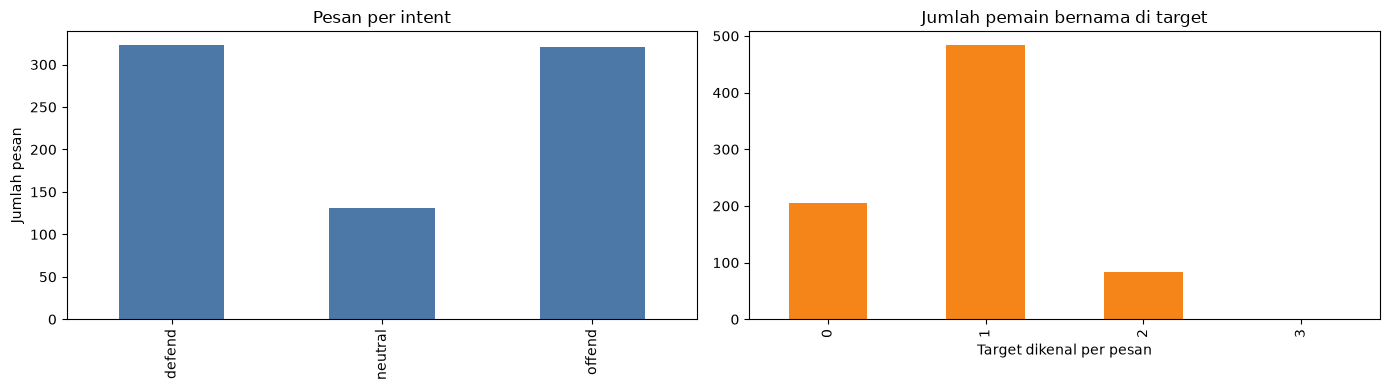

In [6]:
data_target, laporan_eda = run_eda()

## Representasi Pasangan Kandidat

Model 2 tidak menebak nama langsung. Untuk setiap pemain di `daftar_pemain`, satu **pasangan (pesan, kandidat)** dibuat lalu diberi label `offend`, `defend`, atau `tidak_ada`.

Nama pemain disamarkan agar model belajar **pola kalimat**, bukan menghafal nama seperti Budi atau Rani:

- kandidat yang sedang ditanyakan menjadi `KANDIDAT_X`
- pengirim pesan utama menjadi `PENGIRIM_X` (jika bukan kandidat)
- pemain lain menjadi `PEMAIN_X`

Contoh: pesan *"dia pasti pelakunya"* dengan konteks *"Andy dari tadi ngeles"* menjadi teks yang memuat `KANDIDAT_X` di konteks bila kandidatnya Andy, dan `PEMAIN_X` bila kandidatnya pemain lain. Anotasi target di konteks ikut dimasukkan sebagai **memori**.

### Kata Umum dan Nama Panggilan

Chat sering memakai panggilan (`ndy` untuk Andy). Panggilan tidak diketahui game, jadi dikenali dengan aturan sederhana.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `COMMON_WORDS` | Kata yang sering muncul di dataset sumber. | Kata yang muncul di minimal 3 chat asli dan biasanya ditulis huruf kecil di tengah kalimat dianggap kata biasa (misalnya `bisa`, `ini`), sehingga tidak dikira panggilan. Nama seperti `Dika` biasanya ditulis kapital, jadi tidak ikut. |
| `KATA_GANTI / ISTILAH_GAME` | Kata ganti dan istilah game yang bukan nama. | aku/kamu/dia/mereka serta Hitman/Spy/Stalker tidak pernah disamarkan menjadi pemain. |
| `_nama_cocok` | Mengenali potongan nama atau nama berakhiran. | Potongan minimal 3 huruf (`ndy`, `Dika`) atau nama + akhiran (`Budinya`, `Andyy`). Salah ketik tidak ditebak agar kata seperti `gitu` tidak dikira Gita. Panggilan 2 huruf (`Jo`) tidak dikenali. |
| `hanya satu pemain cocok` | Mencegah salah tebak. | Jika sebuah kata cocok untuk dua pemain (misalnya `And` untuk Andy dan Andre), kata itu dibiarkan apa adanya. |

In [7]:
# Token pengganti nama pemain.
TOKEN_KANDIDAT = "KANDIDAT_X"
TOKEN_PENGIRIM = "PENGIRIM_X"
TOKEN_PEMAIN = "PEMAIN_X"
TOKEN_TIDAK_DIKETAHUI = "TIDAK_DIKETAHUI"

# Label Model 2 untuk setiap pasangan (pesan, kandidat).
RELASI_LABELS = ["defend", "offend", "tidak_ada"]

# Kata ganti tidak pernah dianggap nama pemain.
KATA_GANTI = {
    "aku", "saya", "gw", "gue", "gua", "dia", "kamu", "kau", "lu", "lo", "elu",
    "anda", "mereka", "kalian", "kita", "kami", "semua", "si",
}

# Istilah game yang sering ditulis kapital, tetapi bukan nama pemain.
ISTILAH_GAME = {"hitman", "spy", "stalker", "civilian", "hostage", "gag", "order", "guard", "peek", "vote"}


# Mengumpulkan kata yang sering muncul di chat asli agar tidak dikira nama panggilan.
# Kata yang biasanya ditulis kapital di tengah kalimat dianggap nama sehingga tidak dimasukkan.
def build_common_words(source_path, min_count=3):
    counts, total, kapital = Counter(), Counter(), Counter()
    for text in pd.read_csv(source_path)["teks_chat"].dropna().astype(str):
        counts.update(set(re.findall(r"\w+", text.casefold())))
        for index, match in enumerate(re.finditer(r"\w+", text)):
            if index == 0 or text[:match.start()].rstrip().endswith((".", "!", "?")):
                continue
            key = match.group(0).casefold()
            total[key] += 1
            kapital[key] += match.group(0)[:1].isupper()
    return frozenset(
        word for word, count in counts.items()
        if count >= min_count and len(word) >= 2 and kapital[word] <= total[word] * 0.5
    )


# Akhiran yang boleh menempel pada nama, misalnya Budinya.
AKHIRAN_NAMA = ("nya", "lah", "kah", "pun", "mu", "ku")


# Mengenali potongan nama (Dika untuk Andika) atau nama berakhiran (Budinya, Andyy); hasil disimpan agar cepat.
@lru_cache(maxsize=None)
def _nama_cocok(word, name):
    w, n = word.casefold(), name.casefold()
    if len(w) < 3:
        return False
    if w in n:
        return True
    sisa = w[len(n):] if w.startswith(n) else None
    return sisa is not None and (sisa in AKHIRAN_NAMA or set(sisa) == {n[-1]})


COMMON_WORDS = build_common_words(SOURCE_PATH)
print(f"Kata umum dari dataset sumber: {len(COMMON_WORDS)}")

Kata umum dari dataset sumber: 1185


### Menyamarkan Nama

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `samarkan_nama` | Mengganti nama dan panggilan dengan token peran. | Nama persis (tanpa memperhatikan huruf besar) selalu diganti; panggilan hanya jika cocok dengan tepat satu pemain. |
| `kandidat / pengirim` | Menentukan token yang dipakai. | Kandidat selalu `KANDIDAT_X`, walaupun ia juga pengirim; dengan begitu "aku bukan Hitman" dari kandidat terbaca sebagai pembelaan diri. |

In [8]:
# Mengganti nama pemain dan panggilannya dengan token peran agar model tidak menghafal nama.
def samarkan_nama(text, daftar_pemain, kandidat, pengirim, common_words):
    lowered = {name.casefold(): name for name in daftar_pemain}

    def token_for(name):
        if name == kandidat:
            return TOKEN_KANDIDAT
        return TOKEN_PENGIRIM if name == pengirim else TOKEN_PEMAIN

    def replace(match):
        word = match.group(0)
        key = word.casefold()
        if key in lowered:
            return token_for(lowered[key])
        if key in KATA_GANTI or key in ISTILAH_GAME or key in common_words:
            return word
        matches = [name for name in daftar_pemain if _nama_cocok(word, name)]
        return token_for(matches[0]) if len(matches) == 1 else word

    return re.sub(r"\w+", replace, text)

### Teks Pasangan untuk Model

Teks yang sama dipakai oleh SVM, Naive Bayes, dan IndoBERT agar perbandingannya adil.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `intent pesan sekarang` | Label intent pesan yang sedang dinilai (saat training dari dataset, saat game dari Model 1). | Ditulis paling depan (`intent offend || ...`) agar model tahu relasi yang dicari: offend berarti mencari yang dituduh, defend berarti mencari yang dibela. |
| `pesan sekarang` | Pesan yang ditanyakan targetnya. | Ditulis di awal agar tidak terpotong oleh batas token IndoBERT. |
| `konteks` | Riwayat maksimal 12 pesan. | Diurutkan dari yang **terbaru**; jika teks terlalu panjang, pesan paling lama yang terpotong. |
| `[intent: relasi token]` | Anotasi target pesan konteks (memori). | Contoh `[offend: offend KANDIDAT_X]` berarti pesan itu menuduh kandidat; pesan neutral cukup ditulis `[neutral]`. Saat game berjalan, anotasi ini berasal dari prediksi sebelumnya. |

In [9]:
# Menyusun satu teks pasangan (pesan, kandidat) dari pesan utama, konteks, dan roster.
def buat_teks_pasangan(pengirim, teks_chat, chat_sebelumnya, daftar_pemain, kandidat, common_words, label_intent=None):

    def peran(name):
        if name == "tidak_diketahui":
            return TOKEN_TIDAK_DIKETAHUI
        if name == kandidat:
            return TOKEN_KANDIDAT
        return TOKEN_PENGIRIM if name == pengirim else TOKEN_PEMAIN

    # Konteks terbaru ditulis lebih dulu agar yang terpotong adalah pesan paling lama.
    bagian = []
    for pesan in reversed(chat_sebelumnya):
        relasi = ", ".join(f"{t['relasi']} {peran(t['pemain'])}" for t in pesan["target"])
        anotasi = f"{pesan['label_intent']}: {relasi}" if relasi else pesan["label_intent"]
        teks = samarkan_nama(pesan["teks_chat"], daftar_pemain, kandidat, pengirim, common_words)
        bagian.append(f"{peran(pesan['pengirim'])}: {teks} [{anotasi}]")

    sekarang = samarkan_nama(teks_chat, daftar_pemain, kandidat, pengirim, common_words)
    konteks = " | ".join(bagian) if bagian else "tidak ada"
    awal = f"intent {label_intent} || " if label_intent else ""
    return f"{awal}pesan sekarang {peran(pengirim)}: {sekarang} || konteks: {konteks}"

### Membentuk Data Pasangan

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `label_intent != neutral` | Hanya pesan offend/defend yang dipakai. | Pada game, Model 2 hanya dijalankan jika Model 1 memprediksi offend atau defend. |
| `relasi` | Label setiap pasangan. | offend/defend jika kandidat ada di target; selain itu `tidak_ada`. |
| `JUMLAH_PEMAIN_MINIMUM` | Menambah pemain semu yang tidak ikut chat. | Game demo memakai sekitar 6 pemain, sedangkan data pilot rata-rata 3-5. Pemain semu tidak pernah disebut sehingga berlabel `tidak_ada`. Isi 0 untuk mematikan. |
| `row_id / source_group` | Menghubungkan pasangan ke pesan asalnya. | Dipakai untuk menggabungkan prediksi per pesan dan menjaga split per grup. |

In [10]:
# Nama pemain semu untuk melengkapi roster; tidak pernah muncul di chat.
NAMA_SEMU = ["Agus", "Bella", "Candra", "Desi", "Erik", "Fitri", "Galang", "Hesti", "Irwan", "Jessi"]


# Mengubah setiap pesan offend/defend menjadi pasangan (pesan, kandidat) berlabel relasi.
def bentuk_pasangan(data, common_words, jumlah_pemain_minimum=0):
    rows = []
    for row_id, row in data.iterrows():
        if row["label_intent"] == "neutral":
            continue
        gold = {t["pemain"]: t["relasi"] for t in row["target"] if t["pemain"] != "tidak_diketahui"}
        kandidat_list = list(row["daftar_pemain"])
        semu = [name for name in NAMA_SEMU if name.casefold() not in {p.casefold() for p in kandidat_list}]
        kandidat_list += semu[:max(0, jumlah_pemain_minimum - len(kandidat_list))]
        for kandidat in kandidat_list:
            rows.append({
                "row_id": row_id, "session_id": row["session_id"], "source_group": row["source_group"],
                "case_name": row["case_name"], "label_intent": row["label_intent"], "kandidat": kandidat,
                "pemain_semu": kandidat not in row["daftar_pemain"],
                "teks": buat_teks_pasangan(
                    row["pengirim"], row["teks_chat"], row["chat_sebelumnya"],
                    row["daftar_pemain"], kandidat, common_words, row["label_intent"],
                ),
                "relasi": gold.get(kandidat, "tidak_ada"),
            })
    return pd.DataFrame(rows)

### Contoh Teks Pasangan

In [11]:
# Menampilkan semua pasangan dari satu pesan yang targetnya tidak disebut namanya.
contoh_pasangan = bentuk_pasangan(
    data_target[(data_target["case_name"] == "agreement") & (data_target["label_intent"] != "neutral")].head(1),
    COMMON_WORDS, jumlah_pemain_minimum=0,
)
display(contoh_pasangan[["kandidat", "relasi", "teks"]].style.set_properties(
    subset=["teks"], **{"white-space": "normal", "max-width": "900px"},
).hide(axis="index"))

kandidat,relasi,teks
Fajar,defend,"intent defend || pesan sekarang PENGIRIM_X: Iya juga, aku setuju dengan pendapatmu barusan, dia pasti tidak bersalah. || konteks: PEMAIN_X: Bisa saja kan dia sedang membaca riwayat chat karena baru kembali dari toilet, dia civilian kok. [defend: defend KANDIDAT_X] | PEMAIN_X: Padahal kita butuh semua orang buat berdiskusi dan mencari petunjuk bersama. [neutral] | PENGIRIM_X: Iya benar, setuju banget sama teori itu. [offend: offend KANDIDAT_X] | PEMAIN_X: Orang yang terlalu pasif kayak KANDIDAT_X biasanya lagi menyembunyikan sesuatu, dia pasti Hitman. [offend: offend KANDIDAT_X] | PEMAIN_X: KANDIDAT_X belum mengirim chat sejak diskusi dibuka. Ada yang tahu alasannya? [neutral]"
Gilang,tidak_ada,"intent defend || pesan sekarang PENGIRIM_X: Iya juga, aku setuju dengan pendapatmu barusan, dia pasti tidak bersalah. || konteks: PEMAIN_X: Bisa saja kan dia sedang membaca riwayat chat karena baru kembali dari toilet, dia civilian kok. [defend: defend PEMAIN_X] | KANDIDAT_X: Padahal kita butuh semua orang buat berdiskusi dan mencari petunjuk bersama. [neutral] | PENGIRIM_X: Iya benar, setuju banget sama teori itu. [offend: offend PEMAIN_X] | PEMAIN_X: Orang yang terlalu pasif kayak PEMAIN_X biasanya lagi menyembunyikan sesuatu, dia pasti Hitman. [offend: offend PEMAIN_X] | KANDIDAT_X: PEMAIN_X belum mengirim chat sejak diskusi dibuka. Ada yang tahu alasannya? [neutral]"
Hana,tidak_ada,"intent defend || pesan sekarang PENGIRIM_X: Iya juga, aku setuju dengan pendapatmu barusan, dia pasti tidak bersalah. || konteks: PEMAIN_X: Bisa saja kan dia sedang membaca riwayat chat karena baru kembali dari toilet, dia civilian kok. [defend: defend PEMAIN_X] | PEMAIN_X: Padahal kita butuh semua orang buat berdiskusi dan mencari petunjuk bersama. [neutral] | PENGIRIM_X: Iya benar, setuju banget sama teori itu. [offend: offend PEMAIN_X] | KANDIDAT_X: Orang yang terlalu pasif kayak PEMAIN_X biasanya lagi menyembunyikan sesuatu, dia pasti Hitman. [offend: offend PEMAIN_X] | PEMAIN_X: PEMAIN_X belum mengirim chat sejak diskusi dibuka. Ada yang tahu alasannya? [neutral]"
Iwan,tidak_ada,"intent defend || pesan sekarang KANDIDAT_X: Iya juga, aku setuju dengan pendapatmu barusan, dia pasti tidak bersalah. || konteks: PEMAIN_X: Bisa saja kan dia sedang membaca riwayat chat karena baru kembali dari toilet, dia civilian kok. [defend: defend PEMAIN_X] | PEMAIN_X: Padahal kita butuh semua orang buat berdiskusi dan mencari petunjuk bersama. [neutral] | KANDIDAT_X: Iya benar, setuju banget sama teori itu. [offend: offend PEMAIN_X] | PEMAIN_X: Orang yang terlalu pasif kayak PEMAIN_X biasanya lagi menyembunyikan sesuatu, dia pasti Hitman. [offend: offend PEMAIN_X] | PEMAIN_X: PEMAIN_X belum mengirim chat sejak diskusi dibuka. Ada yang tahu alasannya? [neutral]"
Jihan,tidak_ada,"intent defend || pesan sekarang PENGIRIM_X: Iya juga, aku setuju dengan pendapatmu barusan, dia pasti tidak bersalah. || konteks: KANDIDAT_X: Bisa saja kan dia sedang membaca riwayat chat karena baru kembali dari toilet, dia civilian kok. [defend: defend PEMAIN_X] | PEMAIN_X: Padahal kita butuh semua orang buat berdiskusi dan mencari petunjuk bersama. [neutral] | PENGIRIM_X: Iya benar, setuju banget sama teori itu. [offend: offend PEMAIN_X] | PEMAIN_X: Orang yang terlalu pasif kayak PEMAIN_X biasanya lagi menyembunyikan sesuatu, dia pasti Hitman. [offend: offend PEMAIN_X] | PEMAIN_X: PEMAIN_X belum mengirim chat sejak diskusi dibuka. Ada yang tahu alasannya? [neutral]"


## Split, Evaluasi, Penyimpanan Model, dan Prediksi

### Seed Eksperimen

Seed membantu mengulang pengacakan secara konsisten.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `RANDOM_STATE=42` | Acuan pengacakan split, CV, SVM, Optuna, dan IndoBERT. | 42 adalah angka pilihan, bukan tingkat akurasi. |
| `MODEL_DIR` | Folder model Model 2. | Terpisah dari model intent agar tidak saling menimpa. |
| `JUMLAH_PEMAIN_MINIMUM=6` | Ukuran roster minimum saat membentuk pasangan. | Lihat penjelasan pemain semu di atas. |

In [12]:
# Menetapkan seed untuk pembagian data, cross-validation, dan training yang konsisten.
RANDOM_STATE = 42

# Folder penyimpanan model hasil training.
MODEL_DIR = Path("models/target_classifier")

# Roster dilengkapi pemain semu sampai jumlah ini.
JUMLAH_PEMAIN_MINIMUM = 6

### Pembagian Data Latih dan Test

Split dilakukan per **pesan** dan per **grup kalimat sumber**, lalu pasangan dibentuk dari tiap bagian. Semua kandidat dari satu pesan selalu berada di bagian yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `StratifiedGroupKFold` | Membagi data tanpa memisahkan satu grup. | Satu fold (sekitar 20%) menjadi test. Stratifikasi memakai `case_name` agar setiap kasus terwakili di test. |
| `source_group` | Kunci grup. | Kalimat sumber yang sama (original dan variasinya) tidak boleh ada di train dan test sekaligus. |
| `pairs_train / pairs_test` | Data pasangan untuk training dan evaluasi. | Dibentuk setelah split sehingga tidak ada pasangan yang bocor. |
| `train_rows / test_rows` | Pesan asli train dan test. | Dipakai untuk evaluasi per pesan (target lengkap) dan untuk memilih ambang dari data train. |

In [13]:
# Membagi pesan offend/defend per grup kalimat sumber dengan kasus tetap terwakili.
def _split_rows(data, test_size=0.2):
    target_rows = data[data["label_intent"] != "neutral"]
    splitter = StratifiedGroupKFold(n_splits=round(1 / test_size), shuffle=True, random_state=RANDOM_STATE)
    train_index, test_index = next(splitter.split(
        target_rows, target_rows["case_name"], groups=target_rows["source_group"],
    ))
    return target_rows.iloc[train_index], target_rows.iloc[test_index]


# Membaca dataset, membagi pesan, lalu membentuk pasangan untuk train dan test.
def _split_dataset(dataset_path, test_size=0.2):
    data, report = load_target_dataset(dataset_path)
    train_rows, test_rows = _split_rows(data, test_size)
    pairs_train = bentuk_pasangan(train_rows, COMMON_WORDS, JUMLAH_PEMAIN_MINIMUM)
    pairs_test = bentuk_pasangan(test_rows, COMMON_WORDS, JUMLAH_PEMAIN_MINIMUM)
    report = {
        **report, "rows_train": len(train_rows), "rows_test": len(test_rows),
        "pairs_train": len(pairs_train), "pairs_test": len(pairs_test),
        "pair_distribution_train": pairs_train["relasi"].value_counts().to_dict(),
        "pair_distribution_test": pairs_test["relasi"].value_counts().to_dict(),
    }
    return pairs_train, pairs_test, train_rows, test_rows, report

### Arti Metrik Evaluasi

Ada dua tingkat evaluasi. Skala metrik 0-1; umumnya makin tinggi makin baik.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `accuracy / macro-F1 (pasangan)` | Ketepatan per pasangan (pesan, kandidat). | Pasangan `tidak_ada` sangat banyak, jadi accuracy mudah tinggi. Macro-F1 memberi bobot sama untuk defend, offend, dan tidak_ada. |
| `macro-F1 relasi` | Macro-F1 khusus offend dan defend. | Ukuran yang paling jujur untuk kemampuan menemukan relasi. |
| `exact match (pesan)` | Proporsi pesan yang seluruh targetnya benar persis. | Semua pemain dan relasinya harus cocok, termasuk `tidak_diketahui`. Ini metrik utama yang dipakai game. |
| `target F1 (pesan)` | Precision/recall pasangan pemain-relasi bernama. | Tetap memberi nilai sebagian jika satu dari dua target benar. `tidak_diketahui` tidak dihitung di sini. |
| `gabung_target` | Aturan akhir per pesan. | Semua kandidat dengan prediksi offend/defend menjadi target; jika tidak ada, hasilnya `tidak_diketahui` dengan relasi sesuai intent. |

### Aturan Minimal Satu Target

Pesan offend/defend hampir selalu punya target. Jika tidak ada kandidat yang lolos argmax, kandidat dengan peluang relasi sesuai intent tertinggi tetap dipilih bila peluangnya mencapai **ambang**. Pesan yang acuannya memang tidak jelas tetap boleh berakhir `tidak_diketahui`, karena peluangnya di bawah ambang.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `AMBANG_KANDIDAT` | Pilihan ambang yang dicoba. | 0 berarti aturan tidak dipakai. Ambang kecil memaksa lebih banyak target; ambang besar lebih hati-hati. |
| `pilih_ambang` | Memilih ambang dengan exact match pesan tertinggi. | SVM/NB memakai prediksi out-of-fold dari CV per grup di data train; IndoBERT memakai data validation. **Test tidak dipakai untuk memilih.** Jika seri, dipilih ambang terbesar (paling hati-hati). |
| `terapkan_ambang` | Menerapkan aturan pada prediksi pasangan. | Hanya mengubah pesan yang seluruh kandidatnya `tidak_ada`. |
| `exact_match_tanpa_ambang` | Pembanding tanpa aturan. | Menunjukkan seberapa besar aturan ini membantu. |

In [14]:
# -----------------------------------------------------------------------------
# Evaluasi, penyimpanan model, dan prediksi model klasik.
# -----------------------------------------------------------------------------

# Menggabungkan prediksi semua kandidat menjadi target akhir satu pesan.
def gabung_target(prediksi_kandidat, label_intent):
    targets = [{"pemain": kandidat, "relasi": relasi} for kandidat, relasi in prediksi_kandidat if relasi != "tidak_ada"]
    return targets or [{"pemain": "tidak_diketahui", "relasi": label_intent}]


# Menghitung metrik per pasangan.
def _pair_metrics(y_true, y_pred):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_true, y_pred, labels=RELASI_LABELS, average="macro", zero_division=0)), 4),
        "f1_macro_relasi": round(float(f1_score(y_true, y_pred, labels=["offend", "defend"], average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_true, y_pred, labels=RELASI_LABELS, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(y_true, y_pred, labels=RELASI_LABELS, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=RELASI_LABELS).tolist(),
    }


# Menghitung ketepatan target per pesan dari prediksi pasangan.
def _evaluasi_pesan(test_rows, pairs_test, predicted):
    pairs = pairs_test.assign(prediksi=list(predicted))
    records = []
    for row_id, row in test_rows.iterrows():
        group = pairs[pairs["row_id"] == row_id]
        prediksi = gabung_target(zip(group["kandidat"], group["prediksi"]), row["label_intent"])
        gold = {(t["pemain"], t["relasi"]) for t in row["target"]}
        got = {(t["pemain"], t["relasi"]) for t in prediksi}
        gold_known = {x for x in gold if x[0] != "tidak_diketahui"}
        got_known = {x for x in got if x[0] != "tidak_diketahui"}
        records.append({
            "session_id": row["session_id"], "case_name": row["case_name"], "teks_chat": row["teks_chat"],
            "target_asli": sorted(gold), "target_prediksi": sorted(got), "benar_persis": gold == got,
            "tp": len(gold_known & got_known), "fp": len(got_known - gold_known), "fn": len(gold_known - got_known),
        })
    details = pd.DataFrame(records)
    tp, fp, fn = details["tp"].sum(), details["fp"].sum(), details["fn"].sum()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    per_case = details.groupby("case_name")["benar_persis"].agg(jumlah="count", exact_match="mean").round(4)
    return {
        "exact_match": round(float(details["benar_persis"].mean()), 4),
        "target_precision": round(float(precision), 4),
        "target_recall": round(float(recall), 4),
        "target_f1": round(float(2 * precision * recall / (precision + recall)) if precision + recall else 0.0, 4),
        "per_case": per_case, "details": details,
    }


# Pilihan ambang aturan minimal satu target; 0 berarti aturan tidak dipakai.
AMBANG_KANDIDAT = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]


# Pesan offend/defend tanpa target: kandidat dengan peluang relasi sesuai intent tertinggi dipilih jika >= ambang.
def terapkan_ambang(pairs, prediksi, proba, ambang):
    hasil = pd.Series(list(prediksi), index=pairs.index)
    if ambang <= 0:
        return hasil
    for _, grup in pairs.assign(prediksi=hasil.values).groupby("row_id"):
        if (grup["prediksi"] != "tidak_ada").any():
            continue
        intent = grup["label_intent"].iloc[0]
        peluang = proba.loc[grup.index, intent]
        terbaik = peluang.idxmax()
        if peluang[terbaik] >= ambang:
            hasil[terbaik] = intent
    return hasil


# Memilih ambang dengan exact match pesan tertinggi (seri: ambang terbesar yang paling hati-hati).
def pilih_ambang(rows, pairs, proba):
    mentah = proba.idxmax(axis=1)
    skor = [(ambang, _evaluasi_pesan(rows, pairs, terapkan_ambang(pairs, mentah, proba, ambang))["exact_match"])
            for ambang in AMBANG_KANDIDAT]
    terbaik = max(e for _, e in skor)
    return max(a for a, e in skor if e == terbaik), pd.DataFrame(skor, columns=["ambang", "exact_match_pemilihan"])


# Probabilitas relasi tiap pasangan dari model klasik.
def _proba(model, pairs):
    return pd.DataFrame(model.predict_proba(pairs["teks"]), columns=[str(k) for k in model.classes_], index=pairs.index)


# Ambang model klasik dipilih dari prediksi out-of-fold data train (CV per grup), bukan dari test.
def _ambang_dari_cv(model, pairs_train, train_rows, cv_folds=None):
    cv = StratifiedGroupKFold(n_splits=cv_folds or CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    folds = list(cv.split(np.zeros(len(pairs_train)), pairs_train["relasi"], pairs_train["source_group"]))
    oof = cross_val_predict(clone(model), pairs_train["teks"], pairs_train["relasi"], cv=folds,
                            method="predict_proba", n_jobs=CV_N_JOBS)
    proba = pd.DataFrame(oof, columns=sorted(pairs_train["relasi"].unique()), index=pairs_train.index)
    return pilih_ambang(train_rows, pairs_train, proba)


# Menghitung metrik pasangan dan metrik pesan setelah aturan minimal satu target.
def _evaluasi_dengan_ambang(pairs_test, test_rows, proba, ambang):
    mentah = proba.idxmax(axis=1)
    y_pred = terapkan_ambang(pairs_test, mentah, proba, ambang)
    metrics = _pair_metrics(pairs_test["relasi"], y_pred)
    metrics["pesan"] = _evaluasi_pesan(test_rows, pairs_test, y_pred)
    metrics["ambang"] = ambang
    metrics["exact_match_tanpa_ambang"] = _evaluasi_pesan(test_rows, pairs_test, mentah)["exact_match"]
    return metrics


# Memilih ambang dari CV train, lalu menilai model klasik pada test.
def _evaluate(model, pairs_train, train_rows, pairs_test, test_rows, title):
    ambang, _ = _ambang_dari_cv(model, pairs_train, train_rows)
    return _evaluasi_dengan_ambang(pairs_test, test_rows, _proba(model, pairs_test), ambang)


# Versi metrik yang bisa disimpan ke JSON (tabel diubah menjadi list).
def _metrics_json(metrics):
    pesan = metrics["pesan"]
    return {
        **{k: v for k, v in metrics.items() if k != "pesan"},
        "pesan": {
            **{k: v for k, v in pesan.items() if k not in {"per_case", "details"}},
            "per_case": pesan["per_case"].reset_index().to_dict(orient="records"),
        },
    }

### Menyimpan Model Terlatih

Hasil belajar disimpan agar prediksi tidak perlu melatih ulang.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model / joblib.dump` | Menyimpan pipeline ke file .pkl. | Pipeline memuat TF-IDF dan classifier. |
| `pair_builder.json` | Menyimpan daftar kata umum dan token. | Prediksi baru harus membentuk teks pasangan dengan aturan yang sama persis seperti saat training. |
| `ambang_target.json` | Menyimpan ambang tiap model. | Dibaca saat prediksi agar aturan minimal satu target sama dengan saat evaluasi. |

In [15]:
# Menyimpan aturan pembentukan teks pasangan agar prediksi memakai aturan yang sama.
def _save_pair_builder(model_dir):
    output_dir = Path(model_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "pair_builder.json").write_text(json.dumps({
        "common_words": sorted(COMMON_WORDS),
        "tokens": {"kandidat": TOKEN_KANDIDAT, "pengirim": TOKEN_PENGIRIM, "pemain": TOKEN_PEMAIN},
        "labels": RELASI_LABELS,
    }, ensure_ascii=False), encoding="utf-8")


# Menyimpan ambang aturan minimal satu target untuk satu model.
def _save_ambang(model_dir, nama_model, ambang):
    path = Path(model_dir) / "ambang_target.json"
    data = json.loads(path.read_text(encoding="utf-8")) if path.is_file() else {}
    data[nama_model] = float(ambang)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


# Membaca ambang tersimpan; 0 jika belum ada (aturan tidak dipakai).
def _load_ambang(model_dir, nama_model):
    path = Path(model_dir) / "ambang_target.json"
    return float(json.loads(path.read_text(encoding="utf-8")).get(nama_model, 0.0)) if path.is_file() else 0.0


# Menyimpan model klasik ke file agar dapat dipakai lagi untuk prediksi.
def _save_sklearn_model(model, model_dir, filename, ambang=0.0):
    output_dir = Path(model_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model_path = output_dir / filename
    joblib.dump(model, model_path)
    _save_pair_builder(model_dir)
    _save_ambang(model_dir, filename, ambang)
    return model_path

### Prediksi Target SVM dan Naive Bayes

Satu pesan beserta konteks dan roster diubah menjadi pasangan, lalu setiap kandidat diprediksi.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `label_intent` | Intent dari Model 1. | Jika neutral, target langsung kosong tanpa menjalankan Model 2. Jika offend/defend, intent ikut ditulis di teks pasangan. |
| `aturan_minimal_satu` | Aturan minimal satu target dengan ambang tersimpan. | Sama dengan evaluasi. |
| `predict_proba / confidence` | Probabilitas relasi tiap kandidat. | Confidence 90% bukan jaminan prediksi benar. |
| `detail` | Prediksi per kandidat. | Berguna untuk melihat kandidat mana yang hampir dipilih. |

In [16]:
# Memuat daftar kata umum yang disimpan bersama model.
def _load_common_words(model_dir):
    path = Path(model_dir) / "pair_builder.json"
    if not path.is_file():
        raise FileNotFoundError(f"pair_builder.json tidak ditemukan di {model_dir}. Latih model terlebih dahulu.")
    return frozenset(json.loads(path.read_text(encoding="utf-8"))["common_words"])


# Memprediksi target satu pesan dengan model klasik tersimpan.
def predict_target(pengirim, teks_chat, chat_sebelumnya, daftar_pemain, label_intent, model_dir, filename):
    if label_intent == "neutral":
        return [], pd.DataFrame()
    model_path = Path(model_dir) / filename
    if not model_path.is_file():
        raise FileNotFoundError(f"File model tidak ditemukan: {model_path}.")
    model = joblib.load(model_path)
    common_words = _load_common_words(model_dir)
    texts = [buat_teks_pasangan(pengirim, teks_chat, chat_sebelumnya, daftar_pemain, k, common_words, label_intent)
             for k in daftar_pemain]
    probabilities = model.predict_proba(texts)
    labels = [str(label) for label in model.classes_]
    detail = pd.DataFrame(probabilities, columns=labels).assign(kandidat=list(daftar_pemain))
    detail["prediksi"] = [labels[i] for i in probabilities.argmax(axis=1)]
    detail["confidence_persen"] = (probabilities.max(axis=1) * 100).round(2)
    detail = aturan_minimal_satu(detail, label_intent, _load_ambang(model_dir, filename))
    return gabung_target(zip(detail["kandidat"], detail["prediksi"]), label_intent), detail


# Aturan minimal satu target pada prediksi satu pesan (sama dengan terapkan_ambang saat evaluasi).
def aturan_minimal_satu(detail, label_intent, ambang):
    if ambang > 0 and (detail["prediksi"] == "tidak_ada").all() and label_intent in detail:
        terbaik = detail[label_intent].idxmax()
        if detail.loc[terbaik, label_intent] >= ambang:
            detail.loc[terbaik, "prediksi"] = label_intent
    return detail

### Format Hasil Model

Hasil dikemas agar berbagai model dapat dibaca oleh laporan yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model / model_path` | Objek terlatih dan lokasi file. | model untuk pemakaian di memori; model_path untuk memuat model tersimpan. |
| `metrics / data_report` | Metrik model dan catatan dataset. | metrics berisi skor test pasangan dan pesan; data_report berisi ukuran split. |
| `extra` | Informasi tambahan hasil eksperimen. | Misalnya parameter terbaik, skor CV, atau riwayat IndoBERT. |

In [17]:
# Mengemas model, metrik, laporan data, dan lokasi file dalam format hasil yang seragam.
def _result(model, metrics, report, model_path, **extra):
    """Samakan format hasil agar notebook dapat membandingkan semua model."""
    return {"model": model, "metrics": metrics, "data_report": report, "model_path": str(model_path), **extra}

## Persiapan Model dan Tuning

### Model yang Dilatih pada Run Ini

Tiga saklar ini menentukan model mana yang benar-benar dilatih saat notebook dijalankan (Run All). Fungsi training tetap didefinisikan semuanya.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `LATIH_SVM` | Melatih SVM baseline, Grid Search, dan Optuna. | False: cell training dan laporan SVM hanya mencetak "dilewati". |
| `LATIH_NB` | Melatih Naive Bayes baseline, Grid Search, dan Optuna. | False: cell training dan laporan NB hanya mencetak "dilewati". |
| `LATIH_INDOBERT` | Melatih IndoBERT (dipakai bot di game). | False: cell training dan laporan IndoBERT dilewati. |

Tabel perbandingan di akhir hanya berisi model yang dilatih pada run ini. Model lama dengan format teks pasangan berbeda tidak dicampur.

In [18]:
# Saklar model: True = dilatih pada run ini, False = dilewati.
LATIH_SVM = False
LATIH_NB = False
LATIH_INDOBERT = True

### Pengaturan Model Klasik

Pengaturan CV, fitur TF-IDF, pilihan parameter, Grid Search, dan Optuna yang dipakai bersama oleh SVM dan Naive Bayes.

In [19]:
# Model klasik dijalankan pada CPU.
CLASSICAL_DEVICE = "cpu"

# Gunakan seluruh core CPU yang tersedia untuk CV paralel.
CV_N_JOBS = -1

### Pengaturan CV dan Batas Optuna

CV menilai kandidat pada data train; Optuna berhenti sesuai batas trial, waktu, atau stagnasi. Nilainya sama dengan `nlu_baru`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `CV_FOLDS=5` | Jumlah pembagian cross-validation. | Fold dibuat per grup kalimat sumber, sehingga pasangan dari satu pesan tidak terpisah antar-fold. |
| `OPTUNA_MIN_TRIALS=100` | Fase awal sebelum menghitung stagnasi. | Mulai menghitung stagnasi setelah 100 trial COMPLETE. |
| `OPTUNA_PATIENCE=30` | Toleransi trial stagnan setelah fase awal. | Berhenti setelah 30 trial tanpa peningkatan cukup. |
| `OPTUNA_MIN_DELTA=0.001` | Batas kenaikan skor yang dianggap cukup. | 0.001 berarti 0,1 poin persentase macro-F1. |
| `OPTUNA_MAX_TRIALS=500` | Batas jumlah percobaan. | Maksimal 500 trial, bisa berhenti lebih awal. |
| `OPTUNA_TIMEOUT=None` | Batas waktu pencarian. | None berarti tanpa batas waktu. |

In [20]:
# Jumlah fold untuk cross-validation saat tuning.
CV_FOLDS = 5

# Batas trial dan aturan berhenti Optuna saat skor tidak membaik.
OPTUNA_MIN_TRIALS = 100
OPTUNA_PATIENCE = 30
OPTUNA_MIN_DELTA = 0.001
OPTUNA_MAX_TRIALS = 500
OPTUNA_TIMEOUT = None  # Bila diisi, timeout boleh menghentikan sebelum 100 trial.

### TF-IDF Baseline

Baseline adalah pembanding dengan parameter tetap sebelum tuning.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `ngram_range=(1,2)` | Mengambil kata tunggal dan pasangan dua kata. | Contoh `curiga KANDIDAT_X` dan `KANDIDAT_X bukan` dipakai sebagai fitur. |
| `min_df=1 / max_df=0.98` | Menyaring fitur menurut jumlah teks pasangan. | Dibuang jika muncul pada lebih dari 98% teks training. |
| `sublinear_tf=True` | Mengurangi dominasi fitur berulang. | Frekuensi menjadi 1 + log(frekuensi). |
| `strip_accents="unicode"` | Menyeragamkan karakter beraksen. | Variasi aksen dinormalisasi. |

In [21]:
# Membuat pengubah teks menjadi fitur TF-IDF untuk model baseline.
def _baseline_tfidf():
    """Fitur baseline tetap; kalibrasi SVM memakai pipeline lengkap."""
    return TfidfVectorizer(
        ngram_range=(1, 2), min_df=1, max_df=0.98,
        sublinear_tf=True, strip_accents="unicode",
    )

### TF-IDF dan Pilihan Parameter Tuning

Ruang pencarian **sama persis dengan `nlu_baru`**, sehingga perbedaan hasil berasal dari tugasnya, bukan dari pilihan parameter. Daftar `[ ... ]` berisi pilihan yang dicoba saat tuning. Awalan `tfidf__`, `svm__`, dan `nb__` menunjukkan bagian model yang diatur.

| Nama parameter | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `tfidf__min_df / tfidf__max_df` | Membuang fitur terlalu jarang atau terlalu umum. | Jumlah teks pasangan, bukan pengulangan kata dalam satu teks. |
| `tfidf__sublinear_tf` | Mengatur pengaruh fitur berulang. | True: 1 + log(jumlah kemunculan). |
| `tfidf__analyzer` | Bentuk fitur. | `word`: kata atau rangkaian kata; `char_wb`: potongan karakter (SVM saja). |
| `tfidf__ngram_range` | Panjang rangkaian kata/karakter. | Rangkaian lebih panjang menangkap pola seperti `bukan KANDIDAT_X hitman`, tetapi menambah fitur. |
| `svm__C / svm__class_weight` | Regularisasi dan bobot kelas SVM. | `balanced` memberi bobot lebih besar pada offend/defend yang lebih jarang dibanding tidak_ada. |
| `tfidf__use_idf / tfidf__norm / nb__alpha / nb__fit_prior` | Pengaturan khusus NB. | Sama seperti di `nlu_baru`. |

**Nilai lebih besar tidak otomatis lebih bagus.** Kandidat dipilih dari rata-rata macro-F1 cross-validation, bukan skor test.

In [22]:
# Menyediakan pilihan parameter SVM atau Naive Bayes untuk Grid Search dan Optuna.
def _classical_search_spaces(model_kind):
    """Kembalikan grid baru agar mutasi satu eksperimen tidak mengubah lainnya."""
    common = {
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.95, 1.0],
        "tfidf__sublinear_tf": [True, False],
    }
    if model_kind == "svm":
        return [
            {
                **deepcopy(common),
                "tfidf__analyzer": [analyzer],
                "tfidf__ngram_range": ngrams,
                "svm__C": list(SVM_C_VALUES),
                "svm__class_weight": [None, "balanced"],
            }
            for analyzer, ngrams in [
                ("word", [(1, 1), (1, 2), (1, 3)]),
                ("char_wb", [(3, 5), (3, 6)]),
            ]
        ]
    if model_kind == "nb":
        return [{
            **deepcopy(common),
            "tfidf__analyzer": ["word"],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__use_idf": [True, False],
            "tfidf__norm": ["l2", "l1", None],
            "nb__alpha": list(NB_ALPHA_VALUES),
            "nb__fit_prior": [True, False],
        }]
    raise ValueError("model_kind harus 'svm' atau 'nb'.")

### Fold Penilaian dan Kalibrasi

Fold dibuat sekali agar semua kandidat dinilai pada pembagian yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `StratifiedGroupKFold` | Membuat fold tanpa memisahkan grup kalimat sumber. | Berbeda dari `nlu_baru` yang memakai StratifiedKFold, karena satu pesan menghasilkan beberapa pasangan yang harus tetap bersama. |
| `calibration_folds` | Pembagian tambahan untuk confidence SVM. | 3 untuk SVM, 0 untuk NB. Kalibrasi memakai StratifiedKFold biasa di dalam data train fold; ini hanya memengaruhi confidence, bukan pemilihan parameter. |

In [23]:
# Menyiapkan fold CV per grup untuk semua kandidat dan 3 fold kalibrasi khusus SVM.
def _classical_cv(y_train, groups, model_kind, cv_folds):
    cv = StratifiedGroupKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    folds = list(cv.split(np.zeros(len(y_train)), y_train, groups))
    calibration_folds = 3 if model_kind == "svm" else 0
    return folds, calibration_folds

### Proses Grid Search

Mencoba semua kombinasi lalu melatih ulang pemenang pada seluruh train.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `grid / ParameterGrid` | Daftar kombinasi parameter. | 720 kandidat SVM dan 1.920 NB; tiap kandidat menjalani semua fold. |
| `scoring / refit="f1_macro"` | Menilai kandidat dan menentukan pemenang. | Pemilihan hanya berdasarkan rata-rata macro-F1 CV pasangan. |
| `best_params_ / best_estimator_` | Konfigurasi terbaik dan model hasil refit. | Baru dinilai pada test setelah pencarian selesai. |
| `Progress CV` | Skor kandidat terbaik yang semua fold-nya selesai. | Ditampilkan pada progress bar. |

In [24]:
# Membuat pipeline kandidat untuk SVM atau Naive Bayes.
def _classical_model(model_kind, calibration_folds):
    if model_kind == "svm":
        return _calibrated_linear_svm(1.0, None, calibration_folds)
    return Pipeline([
        ("tfidf", TfidfVectorizer(strip_accents="unicode")),
        ("nb", MultinomialNB()),
    ])


# Mencoba semua kombinasi parameter dengan Grid Search, lalu mengevaluasi dan menyimpan model terbaik.
def _train_classical_grid(dataset_path, model_dir, filename, model_kind, cv_folds, n_jobs):
    """Coba seluruh grid pada train CV, refit pemenang, kemudian evaluasi test."""

    pairs_train, pairs_test, train_rows, test_rows, report = _split_dataset(dataset_path)
    x_train, y_train = pairs_train["teks"], pairs_train["relasi"]
    folds, calibration_folds = _classical_cv(y_train, pairs_train["source_group"], model_kind, cv_folds)
    prefix = "estimator__" if model_kind == "svm" else ""
    grid = [{prefix + key: values for key, values in space.items()} for space in _classical_search_spaces(model_kind)]
    model = _classical_model(model_kind, calibration_folds)

    output_root = Path(model_dir) / "grid_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    search = GridSearchCV(
        model, grid, scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"}, cv=folds, n_jobs=n_jobs,
        refit="f1_macro", verbose=0, error_score="raise", return_train_score=False,
    )
    total_fits = len(ParameterGrid(grid)) * len(folds)

    # Hasil fold diambil berurutan dari pekerjaan paralel agar progress bar bisa diperbarui.
    class ProgressParallel(sklearn_search.Parallel):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, return_as="generator", **kwargs)

        def __call__(self, tasks):
            results = []
            best_f1, best_accuracy = None, None
            for result in super().__call__(tasks):
                results.append(result)
                if len(results) % len(folds) == 0:
                    candidate = results[-len(folds):]
                    candidate_f1 = float(np.mean([r["test_scores"]["f1_macro"] for r in candidate]))
                    if best_f1 is None or candidate_f1 > best_f1:
                        best_f1 = candidate_f1
                        best_accuracy = float(np.mean([r["test_scores"]["accuracy"] for r in candidate]))
                if best_f1 is not None:
                    progress.set_postfix(cv_accuracy=f"{best_accuracy:.4f}", cv_macro_f1=f"{best_f1:.4f}", refresh=False)
                progress.update(1)
                if len(results) == total_fits:
                    progress.set_description(f"Grid {model_kind.upper()} - refit terbaik")
            return results

    started = perf_counter()
    with tqdm(total=total_fits, desc=f"Grid {model_kind.upper()} - CV", unit="fit", dynamic_ncols=True) as progress:
        try:
            with patch.object(sklearn_search, "Parallel", ProgressParallel):
                search.fit(x_train, y_train)
        except BaseException:
            progress.set_description(f"Grid {model_kind.upper()} - terhenti")
            raise
        progress.set_description(f"Grid {model_kind.upper()} - selesai")
    search_seconds = perf_counter() - started

    pd.DataFrame(search.cv_results_).to_csv(run_dir / "cv_results.csv", index=False)
    best = {key.removeprefix(prefix): value for key, value in search.best_params_.items()}
    cv_std = float(search.cv_results_["std_test_f1_macro"][search.best_index_])

    model = search.best_estimator_
    metrics = _evaluate(model, pairs_train, train_rows, pairs_test, test_rows, f"{model_kind.upper()} Grid Search")
    path = _save_sklearn_model(model, model_dir, filename, metrics["ambang"])

    summary = {
        "method": "Grid Search", "model_kind": model_kind, "seed": RANDOM_STATE,
        "candidate_count": len(search.cv_results_["params"]),
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_params": best, "cv_f1_macro": float(search.best_score_), "cv_std": cv_std,
        "search_and_refit_seconds": search_seconds,
        "metrics": _metrics_json(metrics), "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, pairs_train, test_rows, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(search.best_score_), 4), cv_std=cv_std,
        run_dir=str(run_dir), training_summary=summary,
    )

### Penghentian Stagnasi Optuna

Stagnasi berarti belum ada kenaikan cukup terhadap skor acuan. Kelas ini sama dengan `nlu_baru`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `completed / stale_trials` | Jumlah trial selesai dan trial stagnan. | Hanya trial COMPLETE dengan skor valid yang dihitung. |
| `reference_best / gain` | Skor acuan dan selisih skor terbaik terhadapnya. | Kenaikan kecil dapat menumpuk sampai mencapai min_delta. |
| `patience / min_delta` | Toleransi stagnasi dan ambang perbaikan. | Perbaikan cukup mereset penghitung menjadi 0. |

In [25]:
class OptunaStagnationStopper:
    """Hentikan study setelah fase awal dan beberapa trial COMPLETE stagnan."""

    def __init__(self, min_trials=100, patience=30, min_delta=0.001):
        self.min_trials = min_trials
        self.patience = patience
        self.min_delta = min_delta
        self.completed = 0
        self.stale_trials = 0
        self.reference_best = None
        self.stop_reason = None

    # Memperbarui perkembangan skor setiap trial dan menghentikan Optuna bila terlalu lama tidak meningkat.
    def __call__(self, study, trial):
        if trial.state.name != "COMPLETE" or trial.value is None or not math.isfinite(trial.value):
            return
        self.completed += 1
        best = float(study.best_value)
        if self.completed <= self.min_trials:
            self.reference_best = best
            self.stale_trials = 0
        else:
            gain = best - self.reference_best
            if gain > 0 and gain + 1e-12 >= self.min_delta:
                self.reference_best = best
                self.stale_trials = 0
            else:
                self.stale_trials += 1
            if self.stale_trials >= self.patience:
                self.stop_reason = "stagnation"
                study.stop()
        study.set_user_attr("stopping_state", self.state())

    def state(self):
        return {
            "completed": self.completed, "stale_trials": self.stale_trials,
            "reference_best": self.reference_best, "stop_reason": self.stop_reason,
        }

### Pemilihan Parameter Optuna

Satu trial berarti satu kombinasi dari daftar pilihan yang sama dengan Grid Search.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `suggest_categorical` | Memilih satu nilai yang akan dicoba. | Misalnya C dipilih dari SVM_C_VALUES. |
| `encoded / ngram_range` | Menyimpan pasangan n-gram sebagai kategori. | Teks 1,2 dikembalikan menjadi tuple (1,2). |

In [26]:
# Meminta Optuna memilih satu kombinasi parameter dari pilihan yang tersedia.
def _suggest_optuna_params(trial, model_kind):
    spaces = _classical_search_spaces(model_kind)
    if model_kind == "svm":
        analyzer = trial.suggest_categorical("analyzer", [space["tfidf__analyzer"][0] for space in spaces])
        space = next(s for s in spaces if s["tfidf__analyzer"] == [analyzer])
    else:
        analyzer, space = "word", spaces[0]
    params = {"tfidf__analyzer": analyzer}
    choices = [f"{low},{high}" for low, high in space["tfidf__ngram_range"]]
    encoded = trial.suggest_categorical(f"{analyzer}_ngram_range", choices)
    params["tfidf__ngram_range"] = tuple(map(int, encoded.split(",")))
    for key, values in space.items():
        if key not in {"tfidf__analyzer", "tfidf__ngram_range"}:
            params[key] = trial.suggest_categorical(key, values)
    return params

### Proses Tuning Optuna

TPE memakai riwayat percobaan untuk membantu memilih kandidat berikutnya.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `study / sampler` | Kumpulan trial dan metode pemilihan parameter. | direction=maximize mencari macro-F1 CV terbesar. |
| `objective / scores` | Menilai satu kandidat pada semua fold per grup. | Mengembalikan rata-rata macro-F1 pasangan. |
| `best / model.fit` | Melatih ulang kandidat terbaik. | Seluruh data train dipakai untuk refit, baru dievaluasi pada test. |
| `stop_reason` | Alasan berhenti. | stagnation, max_trials, atau timeout. |

In [27]:
# Mencari parameter dengan Optuna, melatih ulang kandidat terbaik, lalu mengevaluasi dan menyimpan hasil.
def _train_classical_optuna(
    dataset_path, model_dir, filename, *, model_kind, n_trials, cv_folds,
    timeout, n_jobs, min_trials, patience, min_delta,
):
    stopper = OptunaStagnationStopper(min_trials, patience, min_delta)
    pairs_train, pairs_test, train_rows, test_rows, report = _split_dataset(dataset_path)
    x_train, y_train = pairs_train["teks"], pairs_train["relasi"]
    folds, calibration_folds = _classical_cv(y_train, pairs_train["source_group"], model_kind, cv_folds)
    output_root = Path(model_dir) / "optuna_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.NopPruner(), study_name=f"{model_kind}_macro_f1",
    )

    # Membuat pipeline kandidat dengan parameter pilihan Optuna.
    def build(params):
        model = _classical_model(model_kind, calibration_folds)
        prefix = "estimator__" if model_kind == "svm" else ""
        return model.set_params(**{prefix + key: value for key, value in params.items()})

    # Mengukur rata-rata macro-F1 cross-validation untuk satu kombinasi parameter.
    def objective(trial):
        params = _suggest_optuna_params(trial, model_kind)
        trial.set_user_attr("pipeline_params", params)
        cv_results = cross_validate(
            build(params), x_train, y_train, cv=folds,
            scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"}, n_jobs=n_jobs, error_score="raise",
        )
        scores = cv_results["test_f1_macro"]
        if not np.all(np.isfinite(scores)):
            raise ValueError("Skor CV tidak finite; periksa dataset dan kandidat.")
        trial.set_user_attr("cv_accuracy", float(cv_results["test_accuracy"].mean()))
        trial.set_user_attr("cv_std", float(scores.std()))
        return float(scores.mean())

    def after_trial(study, trial):
        stopper(study, trial)
        if study.best_trials:
            best_trial = study.best_trial
            progress.set_postfix(
                cv_accuracy=f"{best_trial.user_attrs['cv_accuracy']:.4f}", cv_macro_f1=f"{best_trial.value:.4f}",
                stagnasi=f"{stopper.stale_trials}/{patience}", refresh=False,
            )
        progress.update(1)
        study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)

    with tqdm(total=n_trials, desc=f"Optuna {model_kind.upper()}", unit="trial", dynamic_ncols=True) as progress:
        started = perf_counter()
        previous_verbosity = optuna.logging.get_verbosity()
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        try:
            study.optimize(objective, n_trials=n_trials, timeout=timeout, n_jobs=1,
                           callbacks=[after_trial], show_progress_bar=False)
        finally:
            optuna.logging.set_verbosity(previous_verbosity)
            study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)
        search_seconds = perf_counter() - started
        reason = stopper.stop_reason or ("max_trials" if len(study.trials) >= n_trials else "timeout")
        progress.set_description(f"Optuna {model_kind.upper()} - refit ({reason})")
        best = dict(study.best_trial.user_attrs["pipeline_params"])
        best["tfidf__ngram_range"] = tuple(best["tfidf__ngram_range"])
        model = build(best)
        model.fit(x_train, y_train)
        progress.set_description(f"Optuna {model_kind.upper()} - selesai ({reason})")

    metrics = _evaluate(model, pairs_train, train_rows, pairs_test, test_rows, f"{model_kind.upper()} Optuna")
    path = _save_sklearn_model(model, model_dir, filename, metrics["ambang"])
    summary = {
        "method": "Optuna TPE", "search_space": "same_discrete_grid", "model_kind": model_kind,
        "seed": RANDOM_STATE, "optuna_version": optuna.__version__,
        "max_trials": n_trials, "min_trials": min_trials, "patience": patience, "min_delta": min_delta,
        "n_trials_attempted": len(study.trials), "n_trials_completed": stopper.completed,
        "stop_reason": reason, "stopping_state": stopper.state(), "timeout": timeout,
        "search_seconds": search_seconds, "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_trial": study.best_trial.number, "best_params": best, "cv_f1_macro": float(study.best_value),
        "cv_std": float(study.best_trial.user_attrs["cv_std"]),
        "metrics": _metrics_json(metrics), "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, pairs_train, test_rows, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(study.best_value), 4), cv_std=summary["cv_std"],
        study=study, run_dir=str(run_dir), training_summary=summary,
    )

## Laporan dan Evaluasi Model

Contoh chat, penyimpanan laporan, dan tampilan hasil yang digunakan bersama. Eksekusi training ada di section masing-masing model.

### Contoh Chat untuk Pemeriksaan

Sepuluh skenario memperlihatkan perilaku model pada pola penting; terpisah dari evaluasi dataset test.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `TARGET_TEST_CASES` | Skenario lengkap: roster, konteks, pesan, intent, dan target yang diharapkan. | Intent dianggap sudah benar dari Model 1 agar yang diuji hanya Model 2. |
| `Cocok` | Target prediksi sama persis dengan harapan. | Bukan pengganti metrik test. |

In [28]:
# Membuat satu pesan konteks lengkap dengan anotasinya.
def _pesan(pengirim, teks_chat, label_intent="neutral", target=()):
    return {"pengirim": pengirim, "teks_chat": teks_chat, "label_intent": label_intent,
            "target": [{"pemain": p, "relasi": r} for p, r in target]}


# Skenario contoh dengan target yang diharapkan.
TARGET_TEST_CASES = [
    {"nama": "nama langsung", "daftar_pemain": ["Andi", "Budi", "Citra"], "chat_sebelumnya": [],
     "pengirim": "Andi", "teks_chat": "Aku curiga Budi, alibinya berubah terus.", "label_intent": "offend",
     "diharapkan": [("Budi", "offend")]},
    {"nama": "membela diri", "daftar_pemain": ["Andi", "Budi", "Citra"],
     "chat_sebelumnya": [_pesan("Andi", "Citra dari tadi diam, aku curiga dia.", "offend", [("Citra", "offend")])],
     "pengirim": "Citra", "teks_chat": "Aku bukan Hitman, dari tadi aku cuma baca chat.", "label_intent": "defend",
     "diharapkan": [("Citra", "defend")]},
    {"nama": "kata ganti dari konteks", "daftar_pemain": ["Andi", "Budi", "Citra"],
     "chat_sebelumnya": [_pesan("Andi", "Budi dari tadi ngeles terus.", "offend", [("Budi", "offend")])],
     "pengirim": "Citra", "teks_chat": "Iya, dia pasti pelakunya.", "label_intent": "offend",
     "diharapkan": [("Budi", "offend")]},
    {"nama": "relasi campuran", "daftar_pemain": ["Andi", "Budi", "Citra"], "chat_sebelumnya": [],
     "pengirim": "Citra", "teks_chat": "Budi bukan Hitman, justru Andi yang aneh dari tadi.", "label_intent": "offend",
     "diharapkan": [("Budi", "defend"), ("Andi", "offend")]},
    {"nama": "kamu ke pengirim sebelumnya", "daftar_pemain": ["Andi", "Budi", "Citra"],
     "chat_sebelumnya": [_pesan("Budi", "Aku belum mau vote siapa-siapa.")],
     "pengirim": "Andi", "teks_chat": "Kamu dari tadi menghindar terus, kamu Hitman ya?", "label_intent": "offend",
     "diharapkan": [("Budi", "offend")]},
    {"nama": "setuju dengan tuduhan", "daftar_pemain": ["Andi", "Budi", "Citra"],
     "chat_sebelumnya": [_pesan("Andi", "Aku curiga Citra, klaimnya berubah.", "offend", [("Citra", "offend")])],
     "pengirim": "Budi", "teks_chat": "Setuju, aku juga merasa begitu.", "label_intent": "offend",
     "diharapkan": [("Citra", "offend")]},
    {"nama": "rujukan jamak", "daftar_pemain": ["Andi", "Budi", "Citra", "Dodi"],
     "chat_sebelumnya": [_pesan("Andi", "Budi sama Citra saling menutupi dari tadi.", "offend",
                                [("Budi", "offend"), ("Citra", "offend")])],
     "pengirim": "Dodi", "teks_chat": "Mereka berdua memang mencurigakan.", "label_intent": "offend",
     "diharapkan": [("Budi", "offend"), ("Citra", "offend")]},
    {"nama": "saksi bukan target", "daftar_pemain": ["Andi", "Budi", "Citra"], "chat_sebelumnya": [],
     "pengirim": "Andi", "teks_chat": "Dari cerita Citra, aku curiga Budi yang menyandera.", "label_intent": "offend",
     "diharapkan": [("Budi", "offend")]},
    {"nama": "nama panggilan", "daftar_pemain": ["Andika", "Budi", "Citra"], "chat_sebelumnya": [],
     "pengirim": "Budi", "teks_chat": "Jangan vote Dika, dia bukan pelakunya.", "label_intent": "defend",
     "diharapkan": [("Andika", "defend")]},
    {"nama": "acuan tidak jelas", "daftar_pemain": ["Andi", "Budi", "Citra"], "chat_sebelumnya": [],
     "pengirim": "Andi", "teks_chat": "Dia pasti Hitman.", "label_intent": "offend",
     "diharapkan": [("tidak_diketahui", "offend")]},
]

### Catatan Eksperimen Tersimpan

Catatan membantu memeriksa asal hasil tanpa mengubah training.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `summary` | Merekam parameter, skor, dan durasi. | Memisahkan konfigurasi terbaik, CV, dan metrik test. |
| `split_sessions` | Merekam session_id train/test dan grup tiap fold. | Pembagian bisa diperiksa ulang tanpa menjalankan training. |

In [29]:
# Menyimpan ringkasan eksperimen, versi library, dan pembagian data untuk pemeriksaan ulang.
def _save_search_report(run_dir, pairs_train, test_rows, folds, summary):
    summary["environment"] = {
        "python": platform.python_version(), "sklearn": sklearn.__version__,
        "numpy": np.__version__, "pandas": pd.__version__,
    }
    (run_dir / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    split = {
        "train_sessions": sorted(pairs_train["session_id"].unique().tolist()),
        "test_sessions": sorted(test_rows["session_id"].tolist()),
        "cv": [
            {
                "train_groups": sorted(pairs_train.iloc[a]["source_group"].unique().tolist()),
                "validation_groups": sorted(pairs_train.iloc[b]["source_group"].unique().tolist()),
            }
            for a, b in folds
        ],
    }
    (run_dir / "split_sessions.json").write_text(json.dumps(split, indent=2), encoding="utf-8")

### Membaca Laporan Model

Laporan menggunakan hasil training yang sudah selesai, tanpa melatih ulang.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `Tabel pasangan` | Metrik per pasangan (pesan, kandidat). | Macro-F1 relasi hanya menilai offend dan defend. |
| `Tabel pesan` | Exact match dan target F1 per pesan. | Metrik utama untuk dipakai game. |
| `per kasus` | Exact match setiap skenario. | Menunjukkan kasus yang masih lemah, misalnya memori atau rujukan jamak. |
| `chat_table` | Hasil 10 skenario contoh. | expected = target harapan, predicted = hasil model. |

In [30]:
# Menampilkan format laporan yang sama untuk satu model, tanpa melatih ulang model tersebut.
def tampilkan_laporan_model(result, nama_model, waktu_detik, transformer=False):
    metrics = result["metrics"]
    pesan = metrics["pesan"]
    summary = result.get("training_summary", {})
    row = {
        "model": nama_model,
        "accuracy_pasangan": metrics["accuracy"], "macro_f1_pasangan": metrics["f1_macro"],
        "macro_f1_relasi": metrics["f1_macro_relasi"],
        "exact_match_pesan": pesan["exact_match"], "target_f1_pesan": pesan["target_f1"],
        "ambang": metrics.get("ambang", 0.0), "exact_match_tanpa_ambang": metrics.get("exact_match_tanpa_ambang"),
        "waktu_detik": round(waktu_detik, 1),
    }
    if "cv_f1_macro" in result:
        row.update({
            "macro_f1_cv": result["cv_f1_macro"], "std_f1_cv": result["cv_std"],
            "jumlah_kandidat_trial": summary.get("candidate_count", summary.get("n_trials_attempted")),
            "alasan_berhenti": summary.get("stop_reason", "seluruh_grid_selesai"),
        })
    training_table = pd.DataFrame([row])

    print("RINGKASAN EVALUASI:")
    display(training_table[[
        "model", "accuracy_pasangan", "macro_f1_pasangan", "macro_f1_relasi",
        "exact_match_pesan", "exact_match_tanpa_ambang", "ambang", "target_f1_pesan", "waktu_detik",
    ]].rename(columns={
        "model": "Model", "accuracy_pasangan": "Accuracy pasangan", "macro_f1_pasangan": "Macro-F1 pasangan",
        "macro_f1_relasi": "Macro-F1 relasi", "exact_match_pesan": "Exact match pesan",
        "exact_match_tanpa_ambang": "Exact match tanpa ambang", "ambang": "Ambang",
        "target_f1_pesan": "Target F1 pesan", "waktu_detik": "Durasi (detik)",
    }).style.format(precision=4).format({"Durasi (detik)": "{:.1f}"}).hide(axis="index"))

    if "cv_f1_macro" in result:
        print("HASIL PENCARIAN PARAMETER:")
        display(pd.DataFrame([{
            "Macro-F1 CV": result["cv_f1_macro"], "Std CV": result["cv_std"],
            "Kandidat / trial": row["jumlah_kandidat_trial"], "Alasan berhenti": row["alasan_berhenti"],
        }]).style.format({"Macro-F1 CV": "{:.4f}", "Std CV": "{:.4f}"}).hide(axis="index"))
        print("PARAMETER TERBAIK:")
        display(pd.DataFrame([{"Parameter": k, "Nilai": str(v)} for k, v in result["best_params"].items()]).style.hide(axis="index"))

    print(f"Model tersimpan: {result['model_path']}")
    print("LAPORAN PER RELASI (pasangan):")
    print(metrics["classification_report"])
    print("EXACT MATCH PER KASUS (pesan test):")
    display(pesan["per_case"].sort_values("exact_match").style.format({"exact_match": "{:.2f}"}))

    # Skenario contoh dinilai terpisah; tidak dipakai untuk memilih parameter.
    chats = []
    for case in TARGET_TEST_CASES:
        args = (case["pengirim"], case["teks_chat"], case["chat_sebelumnya"], case["daftar_pemain"], case["label_intent"])
        if transformer:
            predicted, _ = predict_transformer_target(*args, MODEL_DIR, device=TRANSFORMER_DEVICE)
        else:
            predicted, _ = predict_target(*args, MODEL_DIR, filename=Path(result["model_path"]).name)
        got = sorted((t["pemain"], t["relasi"]) for t in predicted)
        chats.append({
            "model": nama_model, "skenario": case["nama"], "chat": case["teks_chat"],
            "expected": sorted(case["diharapkan"]), "predicted": got, "benar": got == sorted(case["diharapkan"]),
        })
    chat_table = pd.DataFrame(chats)
    print("HASIL 10 SKENARIO UJI (bukan data pemilihan model):")
    display(chat_table[["skenario", "chat", "expected", "predicted", "benar"]].rename(columns={
        "skenario": "Skenario", "chat": "Pesan", "expected": "Target harapan", "predicted": "Prediksi", "benar": "Cocok",
    }).style.hide(axis="index").set_properties(subset=["Pesan"], **{"white-space": "normal", "max-width": "380px"}))
    display(chat_table.groupby("model")["benar"].agg(jumlah_benar="sum", jumlah_skenario="count", akurasi="mean").reset_index())
    return training_table, chat_table

## SVM

Konfigurasi, kalibrasi, baseline, dan tuning khusus SVM. Fungsi training disiapkan dahulu; cell eksekusi dan laporan berada di akhir section.

### Parameter Khusus SVM

SVM belajar batas pemisah antar-relasi. Nilainya sama dengan `nlu_baru`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `SVM_C_VALUES` | Pilihan C untuk tuning. | Kecil: pembatasan lebih kuat. Besar: lebih mengejar kecocokan training. |
| `SVM_MAX_ITER=10000` | Batas langkah solver. | Bisa selesai lebih cepat bila stabil. |

In [31]:
# Pilihan nilai C untuk tuning SVM.
SVM_C_VALUES = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 4.0, 8.0]

# Batas maksimum iterasi solver LinearSVC.
SVM_MAX_ITER = 10000

### Pipeline dan Kalibrasi SVM

Pipeline menggabungkan TF-IDF dengan classifier. Kalibrasi memetakan skor SVM ke probabilitas untuk confidence.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `c / class_weight` | Mengatur penalti kesalahan. | balanced memberi bobot lebih besar pada relasi yang datanya sedikit. |
| `calibration_cv=3 / sigmoid` | Mengubah skor menjadi probabilitas. | Probabilitas dari fold kalibrasi dirata-ratakan saat prediksi. |

In [32]:
# Membuat pipeline TF-IDF dan SVM dengan kalibrasi agar menghasilkan probabilitas kelas.
def _calibrated_linear_svm(c, class_weight="balanced", calibration_cv=3, *, vectorizer=None):
    pipeline = Pipeline([
        ("tfidf", vectorizer if vectorizer is not None else TfidfVectorizer(strip_accents="unicode")),
        ("svm", LinearSVC(C=c, class_weight=class_weight, random_state=RANDOM_STATE, max_iter=SVM_MAX_ITER)),
    ])
    return CalibratedClassifierCV(
        estimator=pipeline, method="sigmoid",
        cv=StratifiedKFold(n_splits=calibration_cv, shuffle=True, random_state=RANDOM_STATE),
        ensemble=True, n_jobs=1,
    )

### Training SVM Baseline

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `c=2.0 / calibration_cv=3` | Memakai C tetap dan kalibrasi 3 fold. | Sama seperti baseline `nlu_baru`. |
| `model.fit / metrics` | Belajar dari pasangan train lalu dinilai pada test. | Setelah dievaluasi, model disimpan. |

In [33]:
# Melatih SVM baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_svm(dataset_path, model_dir, filename="target_classifier_svm.pkl"):
    pairs_train, pairs_test, train_rows, test_rows, report = _split_dataset(dataset_path)
    model = _calibrated_linear_svm(c=2.0, calibration_cv=3, vectorizer=_baseline_tfidf())
    model.fit(pairs_train["teks"], pairs_train["relasi"])
    metrics = _evaluate(model, pairs_train, train_rows, pairs_test, test_rows, "SVM baseline")
    path = _save_sklearn_model(model, model_dir, filename, metrics["ambang"])
    return _result(model, metrics, report, path)

### Training SVM dengan Grid Search

In [34]:
# Menjalankan pencarian parameter Grid Search khusus untuk SVM.
def train_svm_tuned(dataset_path, model_dir, filename="target_classifier_svm_tuned.pkl", cv_folds=5, *, n_jobs=-1):
    return _train_classical_grid(dataset_path, model_dir, filename, "svm", cv_folds, n_jobs)

### Training SVM dengan Optuna

In [35]:
# Menjalankan pencarian parameter Optuna khusus untuk SVM.
def train_svm_optuna(
    dataset_path, model_dir, filename="target_classifier_svm_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1, min_trials=100, patience=30, min_delta=0.001,
):
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="svm", n_trials=n_trials, cv_folds=cv_folds,
        timeout=timeout, n_jobs=n_jobs, min_trials=min_trials, patience=patience, min_delta=min_delta,
    )

### Jalankan SVM baseline dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_SVM = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `svm_baseline` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_svm_baseline / chat_svm_baseline` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_svm_baseline` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [36]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_SVM:
    _started = perf_counter()
    svm_baseline = train_svm(DATASET_PATH, MODEL_DIR)
    waktu_svm_baseline = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_svm_baseline, 2),
        "test_macro_f1_pasangan": svm_baseline["metrics"]["f1_macro"],
        "test_exact_match_pesan": svm_baseline["metrics"]["pesan"]["exact_match"],
    })
else:
    svm_baseline = None
    print("SVM baseline dilewati karena LATIH_SVM = False.")

SVM baseline dilewati karena LATIH_SVM = False.


In [37]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if svm_baseline is not None:
    hasil_svm_baseline, chat_svm_baseline = tampilkan_laporan_model(svm_baseline, 'SVM baseline', waktu_svm_baseline)
else:
    hasil_svm_baseline, chat_svm_baseline = None, None
    print("Laporan SVM baseline dilewati.")

Laporan SVM baseline dilewati.


### Jalankan SVM Grid Search dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_SVM = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `svm_grid` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_svm_grid / chat_svm_grid` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_svm_grid` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [38]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_SVM:
    _started = perf_counter()
    svm_grid = train_svm_tuned(DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS)
    waktu_svm_grid = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_svm_grid, 2),
        "cv_macro_f1": svm_grid["cv_f1_macro"],
        "test_macro_f1_pasangan": svm_grid["metrics"]["f1_macro"],
        "test_exact_match_pesan": svm_grid["metrics"]["pesan"]["exact_match"],
    })
else:
    svm_grid = None
    print("SVM Grid Search dilewati karena LATIH_SVM = False.")

SVM Grid Search dilewati karena LATIH_SVM = False.


In [39]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if svm_grid is not None:
    hasil_svm_grid, chat_svm_grid = tampilkan_laporan_model(svm_grid, 'SVM Grid Search', waktu_svm_grid)
else:
    hasil_svm_grid, chat_svm_grid = None, None
    print("Laporan SVM Grid Search dilewati.")

Laporan SVM Grid Search dilewati.


### Jalankan SVM Optuna dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_SVM = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `svm_optuna` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_svm_optuna / chat_svm_optuna` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_svm_optuna` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [40]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_SVM:
    _started = perf_counter()
    svm_optuna = train_svm_optuna(
        DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
        n_trials=OPTUNA_MAX_TRIALS, min_trials=OPTUNA_MIN_TRIALS,
        patience=OPTUNA_PATIENCE, min_delta=OPTUNA_MIN_DELTA, timeout=OPTUNA_TIMEOUT,
    )
    waktu_svm_optuna = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_svm_optuna, 2),
        "cv_macro_f1": svm_optuna["cv_f1_macro"],
        "test_macro_f1_pasangan": svm_optuna["metrics"]["f1_macro"],
        "test_exact_match_pesan": svm_optuna["metrics"]["pesan"]["exact_match"],
    })
else:
    svm_optuna = None
    print("SVM Optuna dilewati karena LATIH_SVM = False.")

SVM Optuna dilewati karena LATIH_SVM = False.


In [41]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if svm_optuna is not None:
    hasil_svm_optuna, chat_svm_optuna = tampilkan_laporan_model(svm_optuna, 'SVM Optuna', waktu_svm_optuna)
else:
    hasil_svm_optuna, chat_svm_optuna = None, None
    print("Laporan SVM Optuna dilewati.")

Laporan SVM Optuna dilewati.


## Naive Bayes

Konfigurasi, baseline, dan tuning khusus Naive Bayes. Eksekusi dan laporan memakai fungsi bersama yang sudah didefinisikan.

### Parameter Khusus Naive Bayes

Naive Bayes menilai relasi berdasarkan pola fitur teks per kelas. Nilainya sama dengan `nlu_baru`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `NB_ALPHA_VALUES` | Pilihan smoothing untuk tuning. | Kecil: lebih mengikuti data latih. Besar: peluang fitur lebih merata. |

In [42]:
# Pilihan alpha untuk tuning Naive Bayes.
NB_ALPHA_VALUES = [0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.5, 1.0, 2.0]

### Training Naive Bayes Baseline

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `MultinomialNB(alpha=0.5)` | Smoothing baseline. | Sama seperti baseline `nlu_baru`. |

In [43]:
# Melatih Naive Bayes baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_naive_bayes(dataset_path, model_dir, filename="target_classifier_nb.pkl"):
    pairs_train, pairs_test, train_rows, test_rows, report = _split_dataset(dataset_path)
    model = Pipeline([("tfidf", _baseline_tfidf()), ("nb", MultinomialNB(alpha=0.5))])
    model.fit(pairs_train["teks"], pairs_train["relasi"])
    metrics = _evaluate(model, pairs_train, train_rows, pairs_test, test_rows, "Naive Bayes baseline")
    path = _save_sklearn_model(model, model_dir, filename, metrics["ambang"])
    return _result(model, metrics, report, path)

### Training Naive Bayes dengan Grid Search

In [44]:
# Menjalankan pencarian parameter Grid Search khusus untuk Naive Bayes.
def train_naive_bayes_tuned(dataset_path, model_dir, filename="target_classifier_nb_tuned.pkl", cv_folds=5, *, n_jobs=-1):
    return _train_classical_grid(dataset_path, model_dir, filename, "nb", cv_folds, n_jobs)

### Training Naive Bayes dengan Optuna

In [45]:
# Menjalankan pencarian parameter Optuna khusus untuk Naive Bayes.
def train_naive_bayes_optuna(
    dataset_path, model_dir, filename="target_classifier_nb_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1, min_trials=100, patience=30, min_delta=0.001,
):
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="nb", n_trials=n_trials, cv_folds=cv_folds,
        timeout=timeout, n_jobs=n_jobs, min_trials=min_trials, patience=patience, min_delta=min_delta,
    )

### Jalankan Naive Bayes baseline dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_NB = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `nb_baseline` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_nb_baseline / chat_nb_baseline` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_nb_baseline` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [46]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_NB:
    _started = perf_counter()
    nb_baseline = train_naive_bayes(DATASET_PATH, MODEL_DIR)
    waktu_nb_baseline = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_nb_baseline, 2),
        "test_macro_f1_pasangan": nb_baseline["metrics"]["f1_macro"],
        "test_exact_match_pesan": nb_baseline["metrics"]["pesan"]["exact_match"],
    })
else:
    nb_baseline = None
    print("Naive Bayes baseline dilewati karena LATIH_NB = False.")

Naive Bayes baseline dilewati karena LATIH_NB = False.


In [47]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if nb_baseline is not None:
    hasil_nb_baseline, chat_nb_baseline = tampilkan_laporan_model(nb_baseline, 'Naive Bayes baseline', waktu_nb_baseline)
else:
    hasil_nb_baseline, chat_nb_baseline = None, None
    print("Laporan Naive Bayes baseline dilewati.")

Laporan Naive Bayes baseline dilewati.


### Jalankan NB Grid Search dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_NB = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `nb_grid` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_nb_grid / chat_nb_grid` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_nb_grid` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [48]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_NB:
    _started = perf_counter()
    nb_grid = train_naive_bayes_tuned(DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS)
    waktu_nb_grid = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_nb_grid, 2),
        "cv_macro_f1": nb_grid["cv_f1_macro"],
        "test_macro_f1_pasangan": nb_grid["metrics"]["f1_macro"],
        "test_exact_match_pesan": nb_grid["metrics"]["pesan"]["exact_match"],
    })
else:
    nb_grid = None
    print("NB Grid Search dilewati karena LATIH_NB = False.")

NB Grid Search dilewati karena LATIH_NB = False.


In [49]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if nb_grid is not None:
    hasil_nb_grid, chat_nb_grid = tampilkan_laporan_model(nb_grid, 'NB Grid Search', waktu_nb_grid)
else:
    hasil_nb_grid, chat_nb_grid = None, None
    print("Laporan NB Grid Search dilewati.")

Laporan NB Grid Search dilewati.


### Jalankan NB Optuna dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_NB = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `nb_optuna` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_nb_optuna / chat_nb_optuna` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_nb_optuna` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [50]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_NB:
    _started = perf_counter()
    nb_optuna = train_naive_bayes_optuna(
        DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
        n_trials=OPTUNA_MAX_TRIALS, min_trials=OPTUNA_MIN_TRIALS,
        patience=OPTUNA_PATIENCE, min_delta=OPTUNA_MIN_DELTA, timeout=OPTUNA_TIMEOUT,
    )
    waktu_nb_optuna = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_nb_optuna, 2),
        "cv_macro_f1": nb_optuna["cv_f1_macro"],
        "test_macro_f1_pasangan": nb_optuna["metrics"]["f1_macro"],
        "test_exact_match_pesan": nb_optuna["metrics"]["pesan"]["exact_match"],
    })
else:
    nb_optuna = None
    print("NB Optuna dilewati karena LATIH_NB = False.")

NB Optuna dilewati karena LATIH_NB = False.


In [51]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if nb_optuna is not None:
    hasil_nb_optuna, chat_nb_optuna = tampilkan_laporan_model(nb_optuna, 'NB Optuna', waktu_nb_optuna)
else:
    hasil_nb_optuna, chat_nb_optuna = None, None
    print("Laporan NB Optuna dilewati.")

Laporan NB Optuna dilewati.


## Transformer (IndoBERT)

Konfigurasi, split train/validation/test, fine-tuning, dan inferensi khusus IndoBERT. Pencarian learning rate memakai validation.

### Parameter Training IndoBERT

Pengaturan sama dengan `nlu_baru`, kecuali `max_length` dan pembagian batch karena input berisi konteks sampai 12 pesan.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `TRANSFORMER_EPOCHS=12` | Batas putaran melewati seluruh train. | Bisa berhenti lebih awal karena early stopping. |
| `learning_rates` | Pilihan ukuran langkah pembaruan bobot. | 1e-5, 2e-5, 3e-5; pemenang dipilih dari validation. |
| `validation_size=0.15` | Porsi data pemantau. | Diambil per grup dari pool train (sekitar 16% seluruh data karena pembagian per fold). |
| `max_length=512` | Batas panjang token input. | Batas maksimum IndoBERT. Median teks pasangan sekitar 185 token dan terpanjang sekitar 440, sehingga 256 akan memotong sekitar sepertiga data (konteks terlama yang tempat memori berada). |
| `batch_size=4 / gradient_accumulation_steps=4` | Ukuran batch efektif 16 pasangan. | Sama dengan `nlu_baru` (8 x 2), tetapi dibagi lebih kecil agar teks 512 token muat di GPU 6 GB. |
| `early_stopping_patience=3` | Toleransi evaluasi tanpa perbaikan. | Berhenti setelah 3 epoch tanpa kenaikan macro-F1 validation. |
| `precision="auto"` | Ketelitian komputasi. | BF16 bila didukung, FP16 pada CUDA lain, FP32 pada CPU. |

In [52]:
# Perangkat dan pengaturan fine-tuning IndoBERT.
TRANSFORMER_DEVICE = "cuda"  # Ganti cpu jika GPU CUDA tidak tersedia.

TRANSFORMER_EPOCHS = 12

TRANSFORMER_OPTIONS = {
    "learning_rates": (1e-5, 2e-5, 3e-5),
    "validation_size": 0.15,
    "batch_size": 4,
    "eval_batch_size": 16,
    "gradient_accumulation_steps": 4,
    "max_length": 512,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "linear",
    "dropout": 0.1,
    "label_smoothing_factor": 0.0,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 3,
    "early_stopping_threshold": 0.001,
    "gradient_checkpointing": False,
    "precision": "auto",
    "local_files_only": True,  # Model pralatih harus sudah ada di cache lokal.
}

### Pembagian Data IndoBERT

Validation diperlukan untuk memilih learning rate/checkpoint dan memantau early stopping.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `test_rows` | Test yang sama dengan model klasik. | Memakai `_split_rows` dan seed yang sama. |
| `validation` | Diambil per grup dari pool train. | Tidak ada grup kalimat sumber yang dipakai bersama oleh train, validation, dan test. Validation juga dipakai memilih ambang aturan minimal satu target. |

In [53]:
# Menyiapkan pasangan train, validation, dan test IndoBERT dengan test yang sama seperti model klasik.
def _split_transformer_dataset(dataset_path, validation_size=0.15):
    data, report = load_target_dataset(dataset_path)
    pool_rows, test_rows = _split_rows(data, 0.2)
    splitter = StratifiedGroupKFold(n_splits=max(2, round(0.8 / validation_size)), shuffle=True, random_state=RANDOM_STATE)
    train_index, val_index = next(splitter.split(pool_rows, pool_rows["case_name"], groups=pool_rows["source_group"]))
    train_rows, val_rows = pool_rows.iloc[train_index], pool_rows.iloc[val_index]
    pairs = {name: bentuk_pasangan(rows, COMMON_WORDS, JUMLAH_PEMAIN_MINIMUM)
             for name, rows in (("train", train_rows), ("validation", val_rows), ("test", test_rows))}
    report = {**report, **{f"rows_{name}": len(rows) for name, rows in
                           (("train", train_rows), ("validation", val_rows), ("test", test_rows))},
              **{f"pairs_{name}": len(frame) for name, frame in pairs.items()}}
    return pairs["train"], pairs["validation"], pairs["test"], val_rows, test_rows, report

### Alur Fine-Tuning IndoBERT

Fine-tuning menyesuaikan model pralatih untuk relasi pasangan. Setiap learning rate dimulai dari pretrained dan seed yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `LabelEncoder / id2label` | Memetakan relasi dan indeks angka. | defend, offend, tidak_ada. |
| `metric_for_best_model="f1_macro"` | Menentukan checkpoint terpilih. | Berdasarkan macro-F1 pasangan di validation. |
| `trial_results / best_trial` | Membandingkan learning rate. | Test tidak dipakai untuk memilih. |
| `metrics["pesan"]` | Evaluasi per pesan pada test. | Sama dengan model klasik: exact match dan target F1. |

In [54]:
# Cache model dan tokenizer untuk prediksi IndoBERT berulang.
_TRANSFORMER_INFERENCE_CACHE = {}

# Nama folder model IndoBERT Model 2.
TRANSFORMER_FOLDER = "target_classifier_transformer"


# Melatih IndoBERT, memilih model berdasarkan data validasi, lalu mengevaluasi data uji dan menyimpan hasil.
def train_transformer(
    dataset_path, model_dir, model_name="indobenchmark/indobert-base-p1", epochs=12, max_length=512,
    learning_rate=2e-5, device="cuda", *, learning_rates=None, validation_size=0.15, batch_size=4,
    eval_batch_size=16, gradient_accumulation_steps=4, weight_decay=0.01, warmup_ratio=0.1,
    lr_scheduler_type="linear", dropout=0.1, label_smoothing_factor=0.0, max_grad_norm=1.0,
    early_stopping_patience=3, early_stopping_threshold=0.001, gradient_checkpointing=False,
    precision="auto", local_files_only=True,
):
    # Memastikan perangkat dan presisi valid.
    precision, device = str(precision).lower(), str(device).strip().lower()
    if precision not in {"auto", "fp32", "fp16", "bf16"}:
        raise ValueError("precision harus auto/fp32/fp16/bf16.")
    if device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")
    effective_precision = precision
    if precision == "auto":
        effective_precision = ("bf16" if device == "cuda" and torch.cuda.is_bf16_supported()
                               else "fp16" if device == "cuda" else "fp32")

    # Buang model inferensi lama dari cache sebelum training.
    final_dir = Path(model_dir) / TRANSFORMER_FOLDER
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str(final_dir.resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    rates = list(dict.fromkeys(learning_rates if learning_rates is not None else [learning_rate]))
    pairs_train, pairs_val, pairs_test, val_rows, test_rows, report = _split_transformer_dataset(dataset_path, validation_size)
    encoder = LabelEncoder().fit(RELASI_LABELS)
    labels = encoder.classes_.tolist()
    id2label = dict(enumerate(labels))
    label2id = {label: index for index, label in id2label.items()}

    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=local_files_only)

    # Mengubah teks pasangan menjadi token dan relasi menjadi angka.
    def make_dataset(frame):
        dataset = Dataset.from_dict({"teks": frame["teks"].tolist(), "labels": encoder.transform(frame["relasi"]).tolist()})
        return dataset.map(lambda ex: tokenizer(ex["teks"], truncation=True, max_length=max_length),
                           batched=True, remove_columns=["teks"])

    train_dataset, validation_dataset = make_dataset(pairs_train), make_dataset(pairs_val)
    collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8 if device == "cuda" else None)
    output_root = Path(model_dir) / "transformer_results"
    output_root.mkdir(parents=True, exist_ok=True)
    output_dir = Path(tempfile.mkdtemp(prefix="run_", dir=output_root)).resolve()

    # Menghitung accuracy dan macro-F1 pasangan saat evaluasi IndoBERT.
    def compute_metrics(eval_prediction):
        logits, actual = eval_prediction
        predicted = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(actual, predicted),
            "f1_macro": f1_score(actual, predicted, average="macro", zero_division=0),
            "f1_weighted": f1_score(actual, predicted, average="weighted", zero_division=0),
        }

    trial_results = []
    for trial_index, rate in enumerate(rates, start=1):
        set_seed(RANDOM_STATE)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(labels), id2label=id2label, label2id=label2id,
            hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
            classifier_dropout=dropout, local_files_only=local_files_only,
        )
        if max_length > model.config.max_position_embeddings:
            raise ValueError("max_length melebihi max_position_embeddings model.")
        model.requires_grad_(True)
        model.config.nlu_max_length = max_length
        training_args = TrainingArguments(
            output_dir=str(output_dir / f"trial_{trial_index}"),
            eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
            learning_rate=rate, per_device_train_batch_size=batch_size, per_device_eval_batch_size=eval_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps, num_train_epochs=epochs,
            weight_decay=weight_decay, warmup_ratio=warmup_ratio, lr_scheduler_type=lr_scheduler_type,
            label_smoothing_factor=label_smoothing_factor, max_grad_norm=max_grad_norm,
            gradient_checkpointing=gradient_checkpointing, save_total_limit=1, save_only_model=True,
            report_to="none", disable_tqdm=False, seed=RANDOM_STATE, data_seed=RANDOM_STATE,
            dataloader_num_workers=0, use_cpu=device == "cpu",
            fp16=effective_precision == "fp16", bf16=effective_precision == "bf16", optim="adamw_torch",
        )
        trainer = Trainer(
            model=model, args=training_args, train_dataset=train_dataset, eval_dataset=validation_dataset,
            processing_class=tokenizer, data_collator=collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience,
                                             early_stopping_threshold=early_stopping_threshold)],
        )
        print(f"Transformer trial {trial_index}/{len(rates)} | {model_name} | {device.upper()} | "
              f"pasangan train={len(pairs_train)} val={len(pairs_val)} test={len(pairs_test)} | "
              f"max_epoch={epochs} lr={rate:g}", flush=True)
        trainer.train()
        history = trainer.state.log_history
        best_eval = max((row for row in history if "eval_f1_macro" in row), key=lambda row: row["eval_f1_macro"])
        trial_results.append({
            "trial": trial_index, "learning_rate": rate,
            "best_validation_f1_macro": float(trainer.state.best_metric),
            "best_epoch": float(best_eval["epoch"]), "epochs_trained": float(trainer.state.epoch),
            "best_checkpoint": trainer.state.best_model_checkpoint, "history": history,
        })
        (output_dir / "trials.json").write_text(json.dumps(trial_results, indent=2), encoding="utf-8")
        print(f"Trial {trial_index}: best epoch={best_eval['epoch']}, val macro-F1={trainer.state.best_metric:.4f}", flush=True)
        del trainer, model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    # Memuat checkpoint dari trial terbaik lalu mengevaluasi test.
    best_trial = max(trial_results, key=lambda row: row["best_validation_f1_macro"])
    model = AutoModelForSequenceClassification.from_pretrained(best_trial["best_checkpoint"], local_files_only=True)
    trainer = Trainer(
        model=model,
        args=TrainingArguments(output_dir=str(output_dir / "evaluation"), per_device_eval_batch_size=eval_batch_size,
                               report_to="none", use_cpu=device == "cpu", dataloader_num_workers=0, disable_tqdm=False),
        processing_class=tokenizer, data_collator=collator,
    )
    # Probabilitas relasi; ambang dipilih dari validation, lalu diterapkan pada test.
    def proba_dari(pairs):
        logits = trainer.predict(make_dataset(pairs)).predictions
        logits = logits - logits.max(axis=1, keepdims=True)
        peluang = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
        return pd.DataFrame(peluang, columns=labels, index=pairs.index)

    ambang, tabel_ambang = pilih_ambang(val_rows, pairs_val, proba_dari(pairs_val))
    metrics = _evaluasi_dengan_ambang(pairs_test, test_rows, proba_dari(pairs_test), ambang)

    summary = {
        "model_name": model_name, "seed": RANDOM_STATE, "torch_version": torch.__version__,
        "transformers_version": transformers.__version__, "device": device, "max_epochs": epochs,
        "max_length": max_length, "precision": effective_precision, "optimizer": "adamw_torch",
        "batch_size": batch_size, "gradient_accumulation_steps": gradient_accumulation_steps,
        "data_report": report, "selection_metric": "validation_f1_macro", "test_used_for_selection": False,
        "best_trial": {k: v for k, v in best_trial.items() if k != "history"},
        "trials": trial_results, "run_dir": str(output_dir),
        "ambang": ambang, "pemilihan_ambang": tabel_ambang.to_dict(orient="records"),
    }
    print("\n--- Evaluasi Transformer (test; seleksi hanya dari validation) ---")
    print(f"Best LR: {best_trial['learning_rate']:g} | best epoch: {best_trial['best_epoch']}")
    print(f"Macro-F1 pasangan: {metrics['f1_macro']:.4f} | Exact match pesan: {metrics['pesan']['exact_match']:.4f} "
          f"(tanpa ambang {metrics['exact_match_tanpa_ambang']:.4f}, ambang {ambang:g} dari validation)")

    # Menyimpan model, tokenizer, label encoder, aturan pasangan, dan laporan.
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))
    joblib.dump(encoder, final_dir / "label_encoder.pkl")
    _save_pair_builder(final_dir)
    _save_ambang(final_dir, "transformer", ambang)
    for name, payload in (("metrics.json", _metrics_json(metrics)), ("training_summary.json", summary)):
        (final_dir / name).write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    metrics["pesan"]["details"].to_csv(final_dir / "test_predictions.csv", index=False)
    print(f"Model Transformer tersimpan: {final_dir}")
    return _result(model, metrics, report, final_dir, tokenizer=tokenizer, label_encoder=encoder, training_summary=summary)

### Prediksi Target IndoBERT

Satu pesan diubah menjadi pasangan untuk setiap pemain, lalu semua pasangan diprediksi sekaligus.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `softmax / probabilities` | Probabilitas relasi tiap kandidat. | Tetap confidence model, bukan jaminan benar. |
| `gabung_target / aturan_minimal_satu` | Menggabungkan hasil per kandidat. | Aturan dan ambang sama dengan evaluasi (dibaca dari `ambang_target.json`). |

In [55]:
# Memprediksi target satu pesan dengan IndoBERT tersimpan.
def predict_transformer_target(pengirim, teks_chat, chat_sebelumnya, daftar_pemain, label_intent, model_dir, device="cuda"):
    if label_intent == "neutral":
        return [], pd.DataFrame()
    saved_model_dir = Path(model_dir) / TRANSFORMER_FOLDER
    if not saved_model_dir.is_dir():
        raise FileNotFoundError(f"Model Transformer belum tersedia: {saved_model_dir}")
    cache_key = (str(saved_model_dir.resolve()), device)
    if cache_key not in _TRANSFORMER_INFERENCE_CACHE:
        tokenizer = AutoTokenizer.from_pretrained(saved_model_dir, local_files_only=True)
        model = AutoModelForSequenceClassification.from_pretrained(saved_model_dir, local_files_only=True)
        model.to(torch.device(device)).eval()
        _TRANSFORMER_INFERENCE_CACHE[cache_key] = (tokenizer, model, _load_common_words(saved_model_dir))
    tokenizer, model, common_words = _TRANSFORMER_INFERENCE_CACHE[cache_key]

    texts = [buat_teks_pasangan(pengirim, teks_chat, chat_sebelumnya, daftar_pemain, k, common_words, label_intent)
             for k in daftar_pemain]
    encoded = tokenizer(texts, return_tensors="pt", truncation=True, padding=True,
                        max_length=getattr(model.config, "nlu_max_length", 512))
    encoded = {name: value.to(next(model.parameters()).device) for name, value in encoded.items()}
    with torch.inference_mode():
        probabilities = torch.softmax(model(**encoded).logits, dim=-1).cpu().numpy()
    labels = [model.config.id2label[i] for i in range(probabilities.shape[1])]
    detail = pd.DataFrame(probabilities, columns=labels).assign(kandidat=list(daftar_pemain))
    detail["prediksi"] = [labels[i] for i in probabilities.argmax(axis=1)]
    detail["confidence_persen"] = (probabilities.max(axis=1) * 100).round(2)
    detail = aturan_minimal_satu(detail, label_intent, _load_ambang(saved_model_dir, "transformer"))
    return gabung_target(zip(detail["kandidat"], detail["prediksi"]), label_intent), detail

### Menjalankan Konfigurasi IndoBERT

In [56]:
# Menjalankan IndoBERT menggunakan konfigurasi notebook dan mengganti opsi bila diberikan.
def train_transformer_model(epochs=None, **overrides):
    options = {**TRANSFORMER_OPTIONS, **overrides}
    return train_transformer(
        DATASET_PATH, MODEL_DIR, epochs=TRANSFORMER_EPOCHS if epochs is None else epochs,
        device=TRANSFORMER_DEVICE, **options,
    )

### Jalankan IndoBERT Transformer dan Laporan

Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama. Keduanya dilewati jika `LATIH_INDOBERT = False`.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `transformer_result` | Menyimpan hasil run ini. | Mengulang cell training berarti melatih ulang. None jika dilewati. |
| `hasil_transformer_result / chat_transformer_result` | Tabel metrik dan prediksi skenario contoh. | Cell laporan dapat dijalankan ulang tanpa training. |
| `waktu_transformer_result` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan. |

In [57]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
if LATIH_INDOBERT:
    _started = perf_counter()
    transformer_result = train_transformer_model()
    waktu_transformer_result = perf_counter() - _started

    # Ringkasan akhir training; laporan lengkap ada di cell berikutnya.
    print({
        "train_runtime": round(waktu_transformer_result, 2),
        "test_macro_f1_pasangan": transformer_result["metrics"]["f1_macro"],
        "test_exact_match_pesan": transformer_result["metrics"]["pesan"]["exact_match"],
    })
else:
    transformer_result = None
    print("IndoBERT Transformer dilewati karena LATIH_INDOBERT = False.")

Map:   0%|          | 0/2473 [00:00<?, ? examples/s]

Map:  40%|████      | 1000/2473 [00:00<00:00, 5414.07 examples/s]

Map: 100%|██████████| 2473/2473 [00:00<00:00, 7923.55 examples/s]

Map: 100%|██████████| 2473/2473 [00:00<00:00, 7398.09 examples/s]

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/769 [00:00<?, ? examples/s]

Map: 100%|██████████| 769/769 [00:00<00:00, 4404.69 examples/s]

Map: 100%|██████████| 769/769 [00:00<00:00, 4291.60 examples/s]


--- Evaluasi Transformer (test; seleksi hanya dari validation) ---
Best LR: 3e-05 | best epoch: 10.991922455573505
Macro-F1 pasangan: 0.9661 | Exact match pesan: 0.9453 (tanpa ambang 0.9453, ambang 0.5 dari validation)


Model Transformer tersimpan: models\target_classifier\target_classifier_transformer
{'train_runtime': 1588.85, 'test_macro_f1_pasangan': 0.9661, 'test_exact_match_pesan': 0.9453}


In [58]:
# Menampilkan laporan melalui fungsi bersama (dilewati jika model tidak dilatih pada run ini).
if transformer_result is not None:
    hasil_transformer_result, chat_transformer_result = tampilkan_laporan_model(transformer_result, 'IndoBERT Transformer', waktu_transformer_result, transformer=True)
else:
    hasil_transformer_result, chat_transformer_result = None, None
    print("Laporan IndoBERT Transformer dilewati.")

RINGKASAN EVALUASI:


Model,Accuracy pasangan,Macro-F1 pasangan,Macro-F1 relasi,Exact match pesan,Exact match tanpa ambang,Ambang,Target F1 pesan,Durasi (detik)
IndoBERT Transformer,0.987000,0.966100,0.952700,0.945300,0.945300,0.500000,0.957500,1588.9


Model tersimpan: models\target_classifier\target_classifier_transformer
LAPORAN PER RELASI (pasangan):
              precision    recall  f1-score   support

      defend       0.97      1.00      0.99        73
      offend       0.93      0.91      0.92        56
   tidak_ada       0.99      0.99      0.99       640

    accuracy                           0.99       769
   macro avg       0.96      0.97      0.97       769
weighted avg       0.99      0.99      0.99       769

EXACT MATCH PER KASUS (pesan test):


,jumlah,exact_match
case_name,,
rhetorical_question,5,0.60
short_history_1,3,0.67
first_message_unknown,5,0.80
self,5,0.80
stance_change,5,0.80
witness,5,0.80
explicit,5,1.00
agreement,5,1.00
mixed_relations,5,1.00


HASIL 10 SKENARIO UJI (bukan data pemilihan model):


Skenario,Pesan,Target harapan,Prediksi,Cocok
nama langsung,"Aku curiga Budi, alibinya berubah terus.","[('Budi', 'offend')]","[('Budi', 'offend')]",True
membela diri,"Aku bukan Hitman, dari tadi aku cuma baca chat.","[('Citra', 'defend')]","[('Citra', 'defend')]",True
kata ganti dari konteks,"Iya, dia pasti pelakunya.","[('Budi', 'offend')]","[('Budi', 'offend')]",True
relasi campuran,"Budi bukan Hitman, justru Andi yang aneh dari tadi.","[('Andi', 'offend'), ('Budi', 'defend')]","[('Andi', 'offend'), ('Budi', 'defend')]",True
kamu ke pengirim sebelumnya,"Kamu dari tadi menghindar terus, kamu Hitman ya?","[('Budi', 'offend')]","[('tidak_diketahui', 'offend')]",False
setuju dengan tuduhan,"Setuju, aku juga merasa begitu.","[('Citra', 'offend')]","[('Citra', 'offend')]",True
rujukan jamak,Mereka berdua memang mencurigakan.,"[('Budi', 'offend'), ('Citra', 'offend')]","[('Budi', 'offend'), ('Citra', 'offend')]",True
saksi bukan target,"Dari cerita Citra, aku curiga Budi yang menyandera.","[('Budi', 'offend')]","[('Budi', 'offend')]",True
nama panggilan,"Jangan vote Dika, dia bukan pelakunya.","[('Andika', 'defend')]","[('Andika', 'defend')]",True
acuan tidak jelas,Dia pasti Hitman.,"[('tidak_diketahui', 'offend')]","[('tidak_diketahui', 'offend')]",True


,model,jumlah_benar,jumlah_skenario,akurasi
0,IndoBERT Transformer,9,10,0.9


### Membaca Tabel Epoch

Tabel merangkum hasil tersimpan; tidak melatih ulang atau mengganti nilai metrik.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `ringkasan_trial` | Perbandingan learning rate. | Epoch terbaik bisa lebih awal daripada epoch dijalankan. |
| `Train loss / Val loss` | Kesalahan pada train dan validation. | Nilai lebih kecil umumnya lebih baik. |
| `Val macro-F1` | Kemampuan pada validation (pasangan). | Dipakai memilih checkpoint. |

In [59]:
# Ringkasan kandidat learning rate; data berasal dari hasil training, bukan training ulang.
if transformer_result is None:
    print("Tabel epoch dilewati karena IndoBERT tidak dilatih pada run ini.")
else:
    transformer_summary = transformer_result["training_summary"]
    display(pd.DataFrame([
        {"Trial": t["trial"], "Learning rate": t["learning_rate"], "Epoch terbaik": t["best_epoch"],
         "Epoch dijalankan": t["epochs_trained"], "Val macro-F1 terbaik": t["best_validation_f1_macro"]}
        for t in transformer_summary["trials"]
    ]).style.format({"Learning rate": "{:.0e}", "Epoch terbaik": "{:.0f}", "Epoch dijalankan": "{:.0f}",
                     "Val macro-F1 terbaik": "{:.4f}"}).hide(axis="index"))

    for trial in transformer_summary["trials"]:
        train_rows = [{"Epoch": r["epoch"], "Train loss": r["loss"]} for r in trial["history"] if "loss" in r]
        val_rows = [{"Epoch": r["epoch"], "Val loss": r["eval_loss"], "Val accuracy": r["eval_accuracy"],
                     "Val macro-F1": r["eval_f1_macro"]} for r in trial["history"] if "eval_loss" in r]
        table = pd.DataFrame(train_rows).merge(pd.DataFrame(val_rows), on="Epoch", how="outer").sort_values("Epoch")
        print(f"\nTrial {trial['trial']} | learning rate {trial['learning_rate']:.0e}")
        display(table.style.format(precision=4, na_rep="belum tercatat").format({"Epoch": "{:.0f}"}).hide(axis="index"))

Trial,Learning rate,Epoch terbaik,Epoch dijalankan,Val macro-F1 terbaik
1,1e-05,5,6,0.9263
2,2e-05,7,10,0.9493
3,3e-05,11,12,0.9626



Trial 1 | learning rate 1e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.574500,0.276837,0.871795,0.519325
2,0.221000,0.134155,0.961538,0.905306
3,0.155900,0.124184,0.966346,0.926032
4,0.126300,0.162425,0.959936,0.912075
5,0.101100,0.140801,0.966346,0.926286
6,0.078000,0.186459,0.961538,0.909752



Trial 2 | learning rate 2e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.511700,0.211492,0.935897,0.832472
2,0.190000,0.134433,0.953526,0.885821
3,0.142500,0.123376,0.972756,0.936821
4,0.107600,0.138544,0.971154,0.934876
5,0.064800,0.125641,0.977564,0.947610
6,0.046700,0.193258,0.959936,0.902755
7,0.043700,0.147440,0.977564,0.949318
8,0.028700,0.114251,0.975962,0.945620
9,0.021400,0.110165,0.975962,0.944661
10,0.012600,0.113942,0.977564,0.946570



Trial 3 | learning rate 3e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.476800,0.204012,0.927885,0.847742
2,0.208500,0.151170,0.947115,0.869264
3,0.154500,0.122708,0.967949,0.918659
4,0.122100,0.203286,0.963141,0.915576
5,0.089700,0.127055,0.977564,0.947868
6,0.061400,0.131347,0.969551,0.929699
7,0.046400,0.152180,0.971154,0.936436
8,0.027800,0.094984,0.980769,0.957761
9,0.014900,0.143057,0.977564,0.942863
10,0.012000,0.121857,0.982372,0.961964


## Ringkasan Perbandingan

Jalankan setelah seluruh cell training dan laporan di atas selesai.

### Perbandingan Semua Model

Tabel ini menyatukan baseline, Grid Search, Optuna, dan IndoBERT yang dilatih pada run ini (model yang dilewati lewat saklar `LATIH_*` tidak ikut).

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `Macro-F1 relasi` | Kemampuan menemukan offend/defend pada pasangan. | Tidak terpengaruh banyaknya pasangan tidak_ada. |
| `Exact match pesan` | Proporsi pesan dengan target benar persis. | Metrik utama untuk game. |
| `perbandingan_per_kasus` | Exact match setiap kasus per model. | Menunjukkan model mana yang kuat di kasus sulit (memori, jamak, panggilan). |

Skor berasal dari data test, bukan skenario contoh. Pemilihan parameter tetap memakai CV atau validation.

In [60]:
# Hanya model yang dilatih pada run ini (saklar LATIH_*); model yang dilewati bernilai None.
semua_hasil = {nama: hasil for nama, hasil in {
    "SVM baseline": svm_baseline, "SVM Grid Search": svm_grid, "SVM Optuna": svm_optuna,
    "NB baseline": nb_baseline, "NB Grid Search": nb_grid, "NB Optuna": nb_optuna,
    "IndoBERT": transformer_result,
}.items() if hasil is not None}
assert semua_hasil, "Tidak ada model yang dilatih: nyalakan minimal satu saklar LATIH_*."
print("Model pada perbandingan ini:", ", ".join(semua_hasil))

# Menggabungkan metrik test agar semua model mudah dibandingkan.
tabel_hasil = [t for t in (hasil_svm_baseline, hasil_svm_grid, hasil_svm_optuna, hasil_nb_baseline,
                           hasil_nb_grid, hasil_nb_optuna, hasil_transformer_result) if t is not None]
perbandingan_semua_model = pd.concat(tabel_hasil, ignore_index=True)[[
    "model", "accuracy_pasangan", "macro_f1_pasangan", "macro_f1_relasi",
    "exact_match_pesan", "exact_match_tanpa_ambang", "ambang", "target_f1_pesan", "waktu_detik",
]]
display(perbandingan_semua_model.style.format(precision=4).format({"waktu_detik": "{:.1f}"}).hide(axis="index"))

# Exact match per kasus untuk setiap model.
perbandingan_per_kasus = pd.DataFrame({
    nama: hasil["metrics"]["pesan"]["per_case"]["exact_match"] for nama, hasil in semua_hasil.items()
})
display(perbandingan_per_kasus.style.format("{:.2f}").background_gradient(axis=None, cmap="RdYlGn", vmin=0, vmax=1))

# Hasil skenario contoh semua model.
chat_semua = pd.concat([c for c in (chat_svm_baseline, chat_svm_grid, chat_svm_optuna, chat_nb_baseline,
                                    chat_nb_grid, chat_nb_optuna, chat_transformer_result) if c is not None],
                       ignore_index=True)
display(chat_semua.groupby("model")["benar"].agg(benar_dari_10="sum").reset_index())

MODEL_DIR.mkdir(parents=True, exist_ok=True)
perbandingan_semua_model.to_csv(MODEL_DIR / "perbandingan_semua_model.csv", index=False)
perbandingan_per_kasus.to_csv(MODEL_DIR / "perbandingan_per_kasus.csv")

Model pada perbandingan ini: IndoBERT


model,accuracy_pasangan,macro_f1_pasangan,macro_f1_relasi,exact_match_pesan,exact_match_tanpa_ambang,ambang,target_f1_pesan,waktu_detik
IndoBERT Transformer,0.987000,0.966100,0.952700,0.945300,0.945300,0.500000,0.957500,1588.9


,IndoBERT
case_name,
agreement,1.00
ambiguous,1.00
explicit,1.00
first_message,1.00
first_message_self,1.00
first_message_unknown,0.80
interruption,1.00
memory_outside_window,1.00
mixed_relations,1.00


,model,benar_dari_10
0,IndoBERT Transformer,9


### Catatan Evaluasi

- **Dataset pilot kecil** (sekitar 640 pesan offend/defend, 25 per kasus). Setiap kasus hanya punya sekitar 5 pesan test, jadi exact match per kasus masih sangat bervariasi. Tambah data untuk kasus yang lemah sebelum menarik kesimpulan akhir.
- **Anotasi konteks** pada data ini adalah label yang benar. Saat game berjalan, anotasi berasal dari prediksi sebelumnya sehingga kesalahan bisa merambat; skor di sini adalah batas atas untuk kondisi tersebut.
- **Pemain semu** menambah pasangan `tidak_ada` yang mudah. Karena itu accuracy pasangan cenderung tinggi; gunakan macro-F1 relasi dan exact match pesan sebagai acuan utama.
- **Model klasik** hanya melihat kata dan potongan kata, sehingga kasus kata ganti dan memori bergantung pada token `KANDIDAT_X` di anotasi konteks. IndoBERT dapat membaca urutan kalimat, tetapi tetap dibatasi 512 token.
- **Pemilihan parameter** hanya memakai CV atau validation per grup kalimat sumber; test tidak dipakai untuk memilih.